# Pipeline MCTNet — California + Arkansas (Table 2)
## ÉTAPE 1 : Alignement CDL → ÉTAPE 2 : Cube spectral 10 bandes → ÉTAPE 3 : MCT-Net
## Deux études de zone séparées dans le même notebook

> **Structure attendue :**
> ```
> data/
>   raw/
>     californiaX.SAFE
>     arkansasX.SAFE
>   processed/
>     cdl_california_2021.tif
>     cdl_arkansas_2021.tif
> models/
> ```


## 📦 Imports

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import rasterio
import math
from rasterio.warp import reproject, Resampling as WarpResampling
from rasterio.enums import Resampling
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi']        = 130
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.grid']         = True
plt.rcParams['grid.alpha']        = 0.4
plt.rcParams['grid.linestyle']    = '--'

print(f'PyTorch  : {torch.__version__}')
print(f'Rasterio : {rasterio.__version__}')
gpu = torch.cuda.get_device_name(0) if torch.cuda.is_available() else None
print(f'GPU dispo: {"ok " + gpu if gpu else "CPU uniquement"}')
print('Imports OK')


PyTorch  : 2.11.0+cpu
Rasterio : 1.4.4
GPU dispo: CPU uniquement
Imports OK


## ⚙️ Configuration — Auto-discovery des nouvelles images

> **✅ Après avoir téléchargé de nouvelles images avec `download_sentinel2.py` :**
> Il suffit de **relancer cette cellule** — les nouveaux `.SAFE` sont détectés automatiquement dans `data/raw/` et ajoutés aux `DATES_MAP`.
> Aucune modification manuelle du code n'est nécessaire.

> **Structure des fichiers attendue :**
> ```
> data/raw/
>   S2A_MSIL2A_20210315T184921_..._T10SGH_....SAFE/   ← nouveau téléchargé
>   california1.SAFE/   ← existant
>   arkansas1.SAFE/     ← existant
>   ...
> ```

In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# ⚙️  CONFIGURATION GLOBALE
# ══════════════════════════════════════════════════════════════════════════════

DATA_DIR      = Path('data')
SAFE_DIR      = DATA_DIR / 'raw'
PROCESSED_DIR = DATA_DIR / 'processed'
MODEL_DIR     = Path('models')
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Hyperparamètres — conformes paper Table 3 ────────────────────────────────
N_BANDS           = 10
BANDS_10M         = ['B02', 'B03', 'B04', 'B08']
BANDS_20M         = ['B05', 'B06', 'B07', 'B8A', 'B11', 'B12']
ALL_BANDS         = BANDS_10M + BANDS_20M
TOTAL_SAMPLES     = 10_000
N_TRAIN_PER_CLASS = 240   # ✅ conforme paper Table 2
N_VAL_PER_CLASS   = 60     # ✅ conforme paper
BATCH_SIZE        = 32     # ✅ conforme paper Table 3
LR                = 0.001  # ✅ conforme paper Table 3
EPOCHS            = 400    # marge pour convergence avec early stopping
RANDOM_STATE      = 42
torch.manual_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ══════════════════════════════════════════════════════════════════════════════
# 🔍 AUTO-DISCOVERY — Scan automatique des nouveaux .SAFE téléchargés
# ══════════════════════════════════════════════════════════════════════════════

import re
from datetime import date as _date

def _parse_safe(safe_path, verbose=False):
    """
    Extrait (tile, date_str, granule_dir, file_prefix, doy) depuis un .SAFE.
    VERSION ROBUSTE : cherche les jp2 dans toutes les résolutions + log les échecs.
    FALLBACK : si le nom du .SAFE ne contient pas la date/tuile (ex: california1.SAFE),
               tente de les extraire depuis le dossier GRANULE/L2A_T... interne.
    Retourne None si le format n'est pas reconnu.
    """
    name = safe_path.name
    m = re.search(r'_(\d{8})T\d+_N\d+_R\d+_(T\d+[A-Z]+)_', name)
    
    if not m:
        # ── FALLBACK : lire tile+date depuis le dossier GRANULE interne ──────
        granule_root = safe_path / 'GRANULE'
        if not granule_root.exists():
            if verbose: print(f'    ⚠️  Regex non match + GRANULE absent: {name[:60]}')
            return None
        granule_dirs = list(granule_root.glob('L2A_*'))
        if not granule_dirs:
            if verbose: print(f'    ⚠️  Regex non match + aucun L2A_: {name[:60]}')
            return None
        gname = granule_dirs[0].name
        mg = re.search(r'L2A_(T\d+[A-Z]+)_[A-Z0-9]+_(\d{8})T', gname)
        if not mg:
            if verbose: print(f'    ⚠️  Regex non match (nom + granule): {name[:60]} / {gname[:50]}')
            return None
        tile     = mg.group(1)
        date_str = mg.group(2)
        if verbose: print(f'    ℹ️  Fallback granule OK: {name[:40]} → tile={tile} date={date_str}')
    else:
        date_str = m.group(1)
        tile     = m.group(2)

    try:
        d   = _date(int(date_str[:4]), int(date_str[4:6]), int(date_str[6:8]))
        doy = d.timetuple().tm_yday
    except Exception:
        return None

    granule_root = safe_path / 'GRANULE'
    if not granule_root.exists():
        if verbose: print(f'    ❌ GRANULE absent: {safe_path.name[:60]}')
        return None
    granule_dirs = list(granule_root.glob('L2A_*'))
    if not granule_dirs:
        if verbose: print(f'    ❌ Aucun L2A_ dans GRANULE: {safe_path.name[:60]}')
        return None
    granule_dir = granule_dirs[0].name

    img_data = safe_path / 'GRANULE' / granule_dir / 'IMG_DATA'
    jp2s = []
    for res_folder in ['R10m', 'R20m', 'R60m']:
        res_path = img_data / res_folder
        if res_path.exists():
            found = list(res_path.glob('*_B04*.jp2'))
            if found:
                jp2s = found
                break
    if not jp2s and img_data.exists():
        jp2s = list(img_data.rglob('*_B04*.jp2'))
    if not jp2s:
        if verbose: print(f'    ❌ Aucun B04 jp2 dans {safe_path.name[:50]}')
        return None

    jp2_name = jp2s[0].name
    parts = jp2_name.split('_')
    file_prefix = '_'.join(parts[:2])

    return {'tile': tile, 'date_str': date_str, 'doy': doy,
            'safe_name': safe_path.name, 'granule_dir': granule_dir,
            'file_prefix': file_prefix}


def build_dates_map(safe_dir, tile_to_zone, base_entries, n_total=36, label=''):
    known_keys = set()
    for safe, granule, prefix, zone in base_entries.values():
        if safe != '__pad__.SAFE':
            known_keys.add(prefix[:19])

    new_entries = {}
    for safe_path in sorted(Path(safe_dir).glob('*.SAFE')):
        info = _parse_safe(safe_path, verbose=True)
        if info is None:
            continue
        tile = info['tile']
        if tile not in tile_to_zone:
            continue
        key = info['file_prefix'][:19]
        if key in known_keys:
            continue
        zone     = tile_to_zone[tile]
        date_str = info['date_str']
        name_key = f"new_{tile.lower()}_{date_str}"
        new_entries[name_key] = (
            safe_path.name,
            info['granule_dir'],
            info['file_prefix'],
            zone,
        )
        known_keys.add(key)

    all_real = {**base_entries, **new_entries}
    all_real = {k: v for k, v in all_real.items() if v[0] != '__pad__.SAFE'}
    n_real = len(all_real)
    n_pad  = max(0, n_total - n_real)
    if new_entries:
        print(f'  [{label}] +{len(new_entries)} nouveaux .SAFE détectés : {list(new_entries.keys())}')

    def _doy_from_entry(entry):
        prefix = entry[2]
        try:
            ds = prefix.split('_')[1][:8]
            d  = _date(int(ds[:4]), int(ds[4:6]), int(ds[6:8]))
            return d.timetuple().tm_yday
        except Exception:
            return 999

    sorted_real = dict(sorted(all_real.items(), key=lambda x: _doy_from_entry(x[1])))
    dates_map = dict(sorted_real)
    for i in range(n_pad):
        dates_map[f'pad_{label.lower()}_{n_real+i+1:02d}'] = ('__pad__.SAFE', '__pad__', '__pad__', list(tile_to_zone.values())[0])
    assert len(dates_map) == n_total, f'DATES_MAP {label} : attendu {n_total}, got {len(dates_map)}'
    return dates_map, n_real, n_pad


# ══════════════════════════════════════════════════════════════════════════════
# 🌴 ZONE 1 — CALIFORNIA
# ══════════════════════════════════════════════════════════════════════════════
CDL_CA_INPUT  = PROCESSED_DIR / 'cdl_california_2021.tif'
TRAIN_CSV_CA  = PROCESSED_DIR / 'mctnet_california_360feats.csv'
MODEL_PATH_CA = MODEL_DIR     / 'mctnet_california_final.pth'

CDL_ALIGNED_CA = {
    'SGH': PROCESSED_DIR / 'california_sgh.tif',
    'SFH': PROCESSED_DIR / 'california_sfh.tif',
    'SFG': PROCESSED_DIR / 'california_sfg.tif',
    'SFJ': PROCESSED_DIR / 'california_sfj.tif',
}

S2_REF_CA = {
    'SGH': SAFE_DIR / 'california1.SAFE/GRANULE/L2A_T10SGH_A022833_20210720T185324/IMG_DATA/R10m/T10SGH_20210720T183919_B04_10m.jp2',
    'SFH': SAFE_DIR / 'california10.SAFE/GRANULE/L2A_T10SFH_A022876_20210723T185617/IMG_DATA/R10m/T10SFH_20210723T184919_B04_10m.jp2',
    'SFG': SAFE_DIR / 'california8.SAFE/GRANULE/L2A_T10SFG_A022876_20210723T185617/IMG_DATA/R10m/T10SFG_20210723T184919_B04_10m.jp2',
    'SFJ': SAFE_DIR / 'california9.SAFE/GRANULE/L2A_T10SFJ_A022876_20210723T185617/IMG_DATA/R10m/T10SFJ_20210723T184919_B04_10m.jp2',
}

_BASE_CA = {
    'july_sgh':  ('california1.SAFE',  'L2A_T10SGH_A022833_20210720T185324', 'T10SGH_20210720T183919', 'SGH'),
    'jan_sgh':   ('california3.SAFE',  'L2A_T10SGH_A029239_20210126T184719', 'T10SGH_20210126T184641', 'SGH'),
    'sept_sgh':  ('california4.SAFE',  'L2A_T10SGH_A023734_20210921T185231', 'T10SGH_20210921T184959', 'SGH'),
    'jan_sfg':   ('california5.SAFE',  'L2A_T10SFG_A029239_20210126T184719', 'T10SFG_20210126T184641', 'SFG'),
    'sept_sfg':  ('california6.SAFE',  'L2A_T10SFG_A032714_20210926T185622', 'T10SFG_20210926T185131', 'SFG'),
    'apr_sfg':   ('california7.SAFE',  'L2A_T10SFG_A030426_20210419T190327', 'T10SFG_20210419T184911', 'SFG'),
    'july_sfg':  ('california8.SAFE',  'L2A_T10SFG_A022876_20210723T185617', 'T10SFG_20210723T184919', 'SFG'),
    'july_sfj':  ('california9.SAFE',  'L2A_T10SFJ_A022876_20210723T185617', 'T10SFJ_20210723T184919', 'SFJ'),
    'july_sfh':  ('california10.SAFE', 'L2A_T10SFH_A022876_20210723T185617', 'T10SFH_20210723T184919', 'SFH'),
}

_TILE_ZONE_CA = {'T10SGH': 'SGH', 'T10SFH': 'SFH', 'T10SFG': 'SFG', 'T10SFJ': 'SFJ'}
DATES_MAP_CA, _n_real_ca, _n_pad_ca = build_dates_map(SAFE_DIR, _TILE_ZONE_CA, _BASE_CA, n_total=36, label='CA')

CA_CLASSES = {
    'Grapes'    : [87, 214, 217, 239, 241, 242, 245, 246, 250, 252],
    'Rice'      : [3, 238],
    'Alfalfa'   : [36, 225, 240],
    'Almonds'   : [68, 243, 254],
    'Pistachios': [76, 204, 244],
}
CA_ORDER     = ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']
N_CLASSES_CA = len(CA_ORDER)

# ══════════════════════════════════════════════════════════════════════════════
# 🌾 ZONE 2 — ARKANSAS
# ══════════════════════════════════════════════════════════════════════════════
CDL_AR_INPUT  = PROCESSED_DIR / 'cdl_arkansas_2021.tif'
TRAIN_CSV_AR  = PROCESSED_DIR / 'mctnet_arkansas_360feats.csv'
MODEL_PATH_AR = MODEL_DIR     / 'mctnet_arkansas_final.pth'

CDL_ALIGNED_AR = {
    'SXU': PROCESSED_DIR / 'arkansas_sxu.tif',
}

S2_REF_AR = {
    'SXU': SAFE_DIR / 'arkansas1.SAFE/GRANULE/L2A_T15SXU_A032727_20210927T165058/IMG_DATA/R10m/T15SXU_20210927T164051_B04_10m.jp2',
}

_BASE_AR = {
    'jan_ar':   ('arkansas4.SAFE', 'L2A_T15SXU_A020215_20210118T170017', 'T15SXU_20210118T165629', 'SXU'),
    'apr_ar':   ('arkansas3.SAFE', 'L2A_T15SXU_A021602_20210425T164719', 'T15SXU_20210425T163829', 'SXU'),
    'sept_ar':  ('arkansas1.SAFE', 'L2A_T15SXU_A032727_20210927T165058', 'T15SXU_20210927T164051', 'SXU'),
}

_TILE_ZONE_AR = {'T15SXU': 'SXU'}
DATES_MAP_AR, _n_real_ar, _n_pad_ar = build_dates_map(SAFE_DIR, _TILE_ZONE_AR, _BASE_AR, n_total=36, label='AR')

AR_CLASSES = {
    'Rice'    : [3, 238],
    'Soybeans': [5],
    'Cotton'  : [2],
    'Corn'    : [1],
}
AR_ORDER     = ['Rice', 'Soybeans', 'Cotton', 'Corn', 'Others']
N_CLASSES_AR = len(AR_ORDER)

# ── Résumé ────────────────────────────────────────────────────────────────────
# ── CSV WIDE (mode direct — sans pipeline .SAFE) ─────────────────────────────
TRAIN_CSV_WIDE_CA = Path('CALIFORNIA_10000x360.csv')
TRAIN_CSV_WIDE_AR = Path('ARKANSAS_S2_WIDE_10000x360.csv')

# ── CDL complet USDA NASS ─────────────────────────────────────────────────────
CDL_FULL = {
    1  : 'Corn',          2  : 'Cotton',        3  : 'Rice',
    4  : 'Sorghum',       5  : 'Soybeans',       6  : 'Sunflower',
    10 : 'Peanuts',       11 : 'Tobacco',        12 : 'Sweet Corn',
    21 : 'Winter Wheat',  22 : 'Durum Wheat',    23 : 'Spring Wheat',
    25 : 'Rye',           26 : 'Oats',           27 : 'Millet',
    29 : 'Canola',        30 : 'Flaxseed',       31 : 'Safflower',
    33 : 'Mustard',       34 : 'Alfalfa',        35 : 'Other Hay',
    36 : 'Alfalfa',       37 : 'Dry Beans',      38 : 'Potatoes',
    39 : 'Other Crops',   41 : 'Sugarbeets',     42 : 'Dry Onions',
    43 : 'Cucumbers',     46 : 'Tomatoes',       47 : 'Caneberries',
    48 : 'Watermelons',   49 : 'Onions',         52 : 'Peas',
    58 : 'Cranberries',
    66 : 'Cherries',      67 : 'Peaches',        68 : 'Apples',
    69 : 'Grapes',        71 : 'Other Tree Crops',72 : 'Citrus',
    74 : 'Pecans',        75 : 'Almonds',        76 : 'Walnuts',
    77 : 'Pears',
    204: 'Pistachios',    214: 'Broccoli',       215: 'Avocados',
    216: 'Peppers',       217: 'Pomegranates',   218: 'Nectarines',
    219: 'Greens',        220: 'Plums',          221: 'Strawberries',
    222: 'Squash',        223: 'Apricots',
    225: 'Dbl WinWht/Corn',  238: 'Dbl WinWht/Cotton',
    239: 'Dbl Soybeans/Cotton', 240: 'Dbl Soybeans/Oats',
    241: 'Dbl Corn/Soybeans', 242: 'Blueberries',
    243: 'Cabbage',       244: 'Cauliflower',    246: 'Radishes',
    247: 'Turnips',       248: 'Eggplants',      250: 'Cranberries',
    252: 'Grapes',        254: 'Dbl WinWht/Sunflower',
    61 : 'Fallow/Idle',   62 : 'Pasture/Grass',  63 : 'Forest',
    81 : 'Clouds/NoData', 82 : 'Developed',      83 : 'Water',
    87 : 'Wetlands',      111: 'Open Water',
    121: 'Dev/Open Space',122: 'Dev/Low',         123: 'Dev/Med',
    124: 'Dev/High',      131: 'Barren',
    141: 'Deciduous Forest', 142: 'Evergreen Forest', 143: 'Mixed Forest',
    152: 'Shrubland',     176: 'Grassland/Pasture',
    190: 'Woody Wetlands',195: 'Herb. Wetlands',  999: 'Others',
}

print('=== Configuration ==='  )
print(f'  Device  : {DEVICE}')
print(f'  Bandes  : {ALL_BANDS}\n')
print(f'  [CA] Dates réelles : {_n_real_ca}/36  |  Placeholders : {_n_pad_ca}')
print(f'  [CA] Features: 36 × 10 = 360  ✅')
print(f'  [CA] Classes : {CA_ORDER}')
print(f'  [CA] CDL     : {"✅ " + str(CDL_CA_INPUT) if CDL_CA_INPUT.exists() else "❌ MANQUANT"}\n')
print(f'  [AR] Dates réelles : {_n_real_ar}/36  |  Placeholders : {_n_pad_ar}')
print(f'  [AR] Features: 36 × 10 = 360  ✅')
print(f'  [AR] Classes : {AR_ORDER}')
print(f'  [AR] CDL     : {"✅ " + str(CDL_AR_INPUT) if CDL_AR_INPUT.exists() else "❌ MANQUANT"}')
print(f'\n  ✅ Hyperparamètres conformes paper Table 3 : LR={LR}, batch={BATCH_SIZE}, epochs={EPOCHS}')
print(f'  ✅ CDL_FULL chargé : {len(CDL_FULL)} codes')
for site, csv in [('CA WIDE', TRAIN_CSV_WIDE_CA), ('AR WIDE', TRAIN_CSV_WIDE_AR)]:
    status = '✅' if csv.exists() else '⚠️  non trouvé (pipeline .SAFE utilisé)'
    print(f'  {status}  CSV WIDE {site}: {csv}')
print(f'  ✅ Train/classe : {N_TRAIN_PER_CLASS}  Val/classe : {N_VAL_PER_CLASS}')


    ℹ️  Fallback granule OK: arkansas1.SAFE → tile=T15SXU date=20210927
    ℹ️  Fallback granule OK: arkansas2.SAFE → tile=T15SXU date=20210927
    ℹ️  Fallback granule OK: arkansas3.SAFE → tile=T15SXU date=20210425
    ℹ️  Fallback granule OK: arkansas4.SAFE → tile=T15SXU date=20210118
    ℹ️  Fallback granule OK: california1.SAFE → tile=T10SGH date=20210720
    ℹ️  Fallback granule OK: california10.SAFE → tile=T10SFH date=20210723
    ℹ️  Fallback granule OK: california2.SAFE → tile=T10SGH date=20210720
    ℹ️  Fallback granule OK: california3.SAFE → tile=T10SGH date=20210126
    ℹ️  Fallback granule OK: california4.SAFE → tile=T10SGH date=20210921
    ℹ️  Fallback granule OK: california5.SAFE → tile=T10SFG date=20210126
    ℹ️  Fallback granule OK: california6.SAFE → tile=T10SFG date=20210926
    ℹ️  Fallback granule OK: california7.SAFE → tile=T10SFG date=20210419
    ℹ️  Fallback granule OK: california8.SAFE → tile=T10SFG date=20210723
    ℹ️  Fallback granule OK: california9.SAFE

---
# ÉTAPE 1 — Alignement CDL
### ✅ FIX : Alignement sur DEUX grilles distinctes (SGH et SFH)

In [3]:
import gc
gc.collect()

def align_cdl_to_s2(s2_ref_path, cdl_input_path, output_path, zone_name):
    """Reprojette le CDL sur la grille exacte d'une tuile Sentinel-2."""
    if not Path(s2_ref_path).exists():
        print(f'  ⚠️  Bande réf introuvable pour {zone_name} — SKIP')
        return None, None, None
    print(f'=== Alignement CDL Zone {zone_name} ===')
    with rasterio.open(s2_ref_path) as s2:
        dst_crs = s2.crs; dst_transform = s2.transform
        profile = s2.profile.copy()
        print(f'  CRS: {dst_crs}  |  Bounds: {s2.bounds}')
    profile.update({'dtype': 'uint16', 'count': 1, 'nodata': 0, 'driver': 'GTiff'})
    if output_path.exists(): output_path.unlink()
    with rasterio.open(cdl_input_path) as src:
        with rasterio.open(output_path, 'w', **profile) as dst:
            reproject(source=rasterio.band(src, 1), destination=rasterio.band(dst, 1),
                      src_transform=src.transform, src_crs=src.crs,
                      dst_transform=dst_transform, dst_crs=dst_crs,
                      resampling=WarpResampling.nearest)
    print(f'✅ CDL {zone_name} aligné → {output_path}\n')
    return profile, dst_transform, dst_crs

def align_all_zones(s2_ref_dict, cdl_input_path, cdl_aligned_dict, label):
    """Aligne le CDL sur toutes les zones d'une étude."""
    print(f'\n{"="*60}')
    print(f'  Alignement CDL — {label}')
    print(f'{"="*60}')
    profiles = {}
    for zone in sorted(s2_ref_dict.keys()):
        p, t, c = align_cdl_to_s2(s2_ref_dict[zone], cdl_input_path, cdl_aligned_dict[zone], zone)
        profiles[zone] = {'ok': p is not None, 'profile': p, 'transform': t, 'crs': c}
    return profiles

# ── California ────────────────────────────────────────────────────────────────
zone_profiles_CA = align_all_zones(S2_REF_CA, CDL_CA_INPUT, CDL_ALIGNED_CA, 'CALIFORNIA')

# ── Arkansas ──────────────────────────────────────────────────────────────────
zone_profiles_AR = align_all_zones(S2_REF_AR, CDL_AR_INPUT, CDL_ALIGNED_AR, 'ARKANSAS')

print('\n=== Résumé alignement ===')
for zone, info in zone_profiles_CA.items(): print(f'  CA-{zone}: {"✅" if info["ok"] else "❌"}')
for zone, info in zone_profiles_AR.items(): print(f'  AR-{zone}: {"✅" if info["ok"] else "❌"}')



  Alignement CDL — CALIFORNIA
=== Alignement CDL Zone SFG ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=600000.0, bottom=4090200.0, right=709800.0, top=4200000.0)
✅ CDL SFG aligné → data\processed\california_sfg.tif

=== Alignement CDL Zone SFH ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=600000.0, bottom=4190220.0, right=709800.0, top=4300020.0)
✅ CDL SFH aligné → data\processed\california_sfh.tif

=== Alignement CDL Zone SFJ ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=600000.0, bottom=4290240.0, right=709800.0, top=4400040.0)
✅ CDL SFJ aligné → data\processed\california_sfj.tif

=== Alignement CDL Zone SGH ===
  CRS: EPSG:32610  |  Bounds: BoundingBox(left=699960.0, bottom=4190220.0, right=809760.0, top=4300020.0)
✅ CDL SGH aligné → data\processed\california_sgh.tif


  Alignement CDL — ARKANSAS
=== Alignement CDL Zone SXU ===
  CRS: EPSG:32615  |  Bounds: BoundingBox(left=600000.0, bottom=3790200.0, right=709800.0, top=3900000.0)
✅ CDL SXU aligné → data\processed\

### 🔍 Inspection du CDL aligné

=== California (Zone SGH) ===
  CRS: EPSG:32610  |  Taille: 10980×10980 px
  Classes agricoles: 55  |  Pixels: 120,560,400


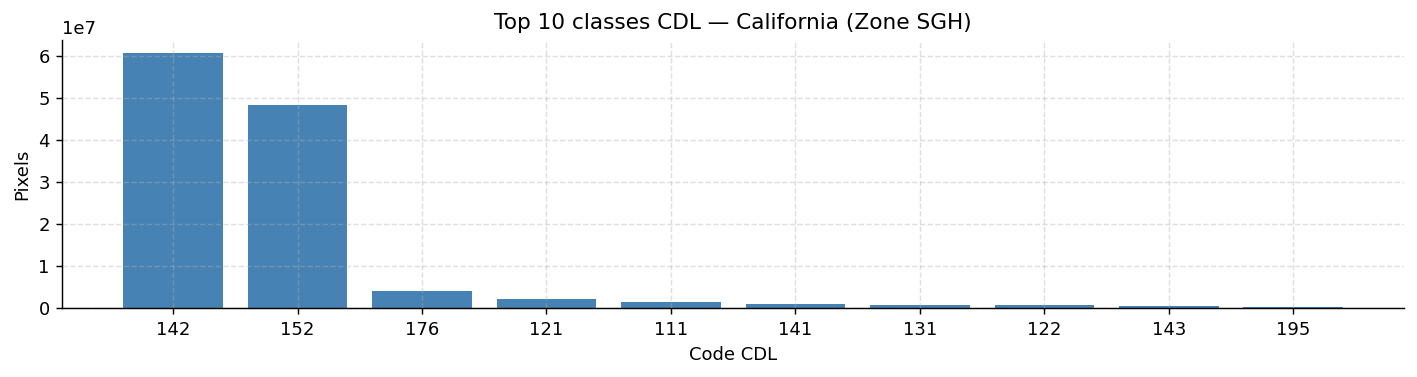

=== Arkansas (Zone SXU) ===
  CRS: EPSG:32615  |  Taille: 10980×10980 px
  Classes agricoles: 43  |  Pixels: 119,683,812


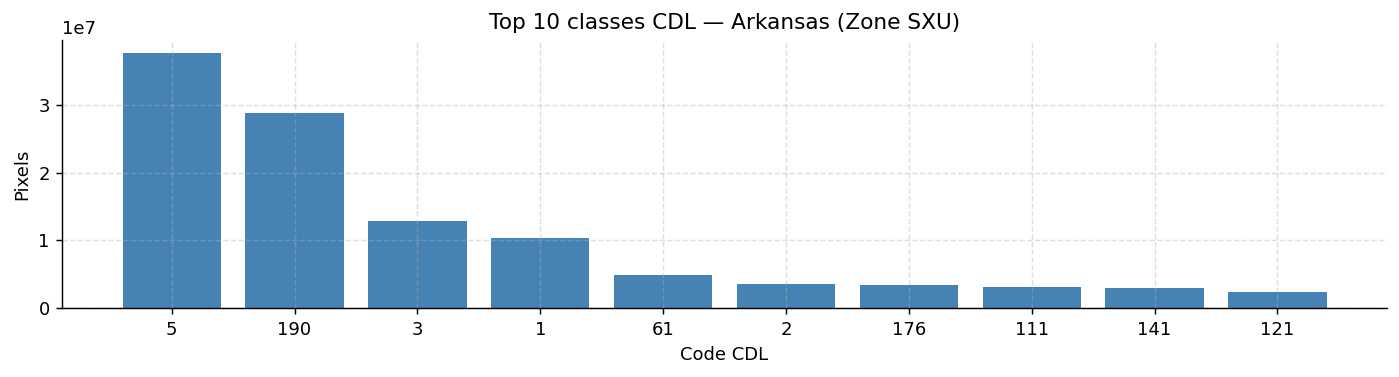

✅ Inspection CDL terminée


In [4]:
def inspect_cdl(cdl_path, title):
    with rasterio.open(cdl_path) as dst:
        print(f'=== {title} ===')
        print(f'  CRS: {dst.crs}  |  Taille: {dst.width}×{dst.height} px')
        data = dst.read(1)
    uniq, cnt = np.unique(data[data > 0], return_counts=True)
    print(f'  Classes agricoles: {len(uniq)}  |  Pixels: {cnt.sum():,}')
    fig, ax = plt.subplots(figsize=(11, 3))
    top10 = sorted(zip(cnt, uniq), reverse=True)[:10]
    tc, tk = zip(*top10)
    ax.bar([str(int(c)) for c in tk], tc, color='steelblue')
    ax.set_title(f'Top 10 classes CDL — {title}')
    ax.set_xlabel('Code CDL'); ax.set_ylabel('Pixels')
    plt.tight_layout(); plt.show()

inspect_cdl(CDL_ALIGNED_CA['SGH'], 'California (Zone SGH)')
if zone_profiles_AR['SXU']['ok']:
    inspect_cdl(CDL_ALIGNED_AR['SXU'], 'Arkansas (Zone SXU)')
print('✅ Inspection CDL terminée')


---
# ÉTAPE 2 — Échantillonnage 10 000 pixels (Table 2)
### ✅ FIX : `Nb of Samples` = total sélectionné (train+val+test), pas les pixels disponibles

In [5]:
def build_code_to_class(classes_dict):
    """Construit le mapping code CDL → nom de classe."""
    mapping = {}
    for name, codes in classes_dict.items():
        for c in codes:
            mapping[c] = name
    return mapping

CODE_TO_CLASS_CA = build_code_to_class(CA_CLASSES)
CODE_TO_CLASS_AR = build_code_to_class(AR_CLASSES)

print('Classes California :', list(CA_CLASSES.keys()) + ['Others'])
print('Classes Arkansas   :', list(AR_CLASSES.keys()) + ['Others'])


Classes California : ['Grapes', 'Rice', 'Alfalfa', 'Almonds', 'Pistachios', 'Others']
Classes Arkansas   : ['Rice', 'Soybeans', 'Cotton', 'Corn', 'Others']


In [6]:

def build_class_data(cdl_aligned_dict, zone_profiles, code_to_class, order,
                        n_target=TOTAL_SAMPLES * 3, chunk_rows=1024, rng_seed=RANDOM_STATE):
    """
    Lecture CDL par blocs + réservoir vectorisé 100% numpy.
    Mémoire max : chunk_rows × width × 1 octet. Pas de boucle Python par pixel.
    """
    rng = np.random.default_rng(rng_seed)
    zone_data = {}

    # Réservoirs pré-alloués taille fixe
    res_rows  = {cls: np.empty(n_target, np.int32)  for cls in order}
    res_cols  = {cls: np.empty(n_target, np.int32)  for cls in order}
    res_zones = {cls: np.empty(n_target, object)    for cls in order}
    res_fill  = {cls: 0 for cls in order}  # pixels dans le réservoir
    res_seen  = {cls: 0 for cls in order}  # pixels vus au total

    for zone, info in zone_profiles.items():
        if not info['ok']:
            print(f'  Zone {zone}: ⚠️ non disponible'); continue

        with rasterio.open(cdl_aligned_dict[zone]) as src:
            H, W = src.height, src.width
            zone_data[zone] = {'shape': (H, W)}
            zone_seen = 0  # pixels agricoles vus dans cette zone

            for row_off in range(0, H, chunk_rows):
                win   = rasterio.windows.Window(0, row_off, W, min(chunk_rows, H - row_off))
                chunk = src.read(1, window=win)
                ag    = chunk > 0
                if not ag.any(): continue

                rl, cl = np.where(ag)
                rg     = (rl + row_off).astype(np.int32)
                codes  = chunk[rl, cl].astype(np.int32)
                cl     = cl.astype(np.int32)

                for code in np.unique(codes):
                    cls   = code_to_class.get(int(code), 'Others')
                    sel   = codes == code
                    rc    = rg[sel]; cc = cl[sel]
                    n_new = len(rc)
                    fill  = res_fill[cls]
                    seen  = res_seen[cls]

                    if fill < n_target:
                        # --- Phase remplissage direct ---
                        room = n_target - fill
                        take = min(n_new, room)
                        res_rows[cls][fill:fill+take]  = rc[:take]
                        res_cols[cls][fill:fill+take]  = cc[:take]
                        res_zones[cls][fill:fill+take] = zone
                        res_fill[cls] += take
                        res_seen[cls] += take
                        if take == n_new: continue
                        # reste à traiter en mode réservoir
                        rc = rc[take:]; cc = cc[take:]
                        n_new -= take
                        seen  = res_seen[cls]

                    # --- Phase réservoir vectorisée ---
                    # Pour chaque pixel i (0..n_new-1), tire j ~ U[0, seen+i]
                    # Remplace position j si j < n_target
                    i_idx = np.arange(n_new, dtype=np.int64)
                    j     = (rng.random(n_new) * (seen + i_idx + 1)).astype(np.int64)
                    keep  = j < n_target
                    if keep.any():
                        pos = j[keep].astype(np.int32)
                        res_rows[cls][pos]  = rc[keep]
                        res_cols[cls][pos]  = cc[keep]
                        res_zones[cls][pos] = zone
                    res_seen[cls] += n_new
                    zone_seen += n_new

        print(f'  Zone {zone}: {H}×{W} ✅  ({zone_seen:,} px agricoles vus)')

    class_data = {}
    for cls in order:
        n = res_fill[cls]
        class_data[cls] = {
            'rows':  res_rows[cls][:n],
            'cols':  res_cols[cls][:n],
            'zones': res_zones[cls][:n],
        }
    return class_data, zone_data

print('=== Extraction pixels — California ===')
class_data_CA, zone_data_CA = build_class_data(CDL_ALIGNED_CA, zone_profiles_CA, CODE_TO_CLASS_CA, CA_ORDER)
print('\nPixels disponibles par classe [CA]:')
for cls in CA_ORDER:
    n = len(class_data_CA[cls]['rows'])
    ok = '✅' if n >= N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + 1 else '❌ INSUFFISANT'
    print(f'  {ok}  {cls:<12}: {n:>12,} px')

print('\n=== Extraction pixels — Arkansas ===')
class_data_AR, zone_data_AR = build_class_data(CDL_ALIGNED_AR, zone_profiles_AR, CODE_TO_CLASS_AR, AR_ORDER)
print('\nPixels disponibles par classe [AR]:')
for cls in AR_ORDER:
    n = len(class_data_AR[cls]['rows'])
    ok = '✅' if n >= N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + 1 else '❌ INSUFFISANT'
    print(f'  {ok}  {cls:<12}: {n:>12,} px')


=== Extraction pixels — California ===
  Zone SFG: 10980×10980 ✅  (120,383,728 px agricoles vus)
  Zone SFH: 10980×10980 ✅  (120,557,072 px agricoles vus)
  Zone SFJ: 10980×10980 ✅  (120,560,400 px agricoles vus)
  Zone SGH: 10980×10980 ✅  (120,560,400 px agricoles vus)

Pixels disponibles par classe [CA]:
  ✅  Grapes      :       30,000 px
  ✅  Rice        :       30,000 px
  ✅  Alfalfa     :       30,000 px
  ✅  Almonds     :       30,000 px
  ✅  Pistachios  :       30,000 px
  ✅  Others      :       30,000 px

=== Extraction pixels — Arkansas ===
  Zone SXU: 10980×10980 ✅  (119,533,812 px agricoles vus)

Pixels disponibles par classe [AR]:
  ✅  Rice        :       30,000 px
  ✅  Soybeans    :       30,000 px
  ✅  Cotton      :       30,000 px
  ✅  Corn        :       30,000 px
  ✅  Others      :       30,000 px


In [7]:
def sample_pixels(class_data, order, n_classes, rng_seed=RANDOM_STATE):
    """Échantillonne exactement TOTAL_SAMPLES pixels avec split train/val/test."""
    rng = np.random.default_rng(rng_seed)
    N_MIN = N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + 1
    test_budget = TOTAL_SAMPLES - n_classes * (N_TRAIN_PER_CLASS + N_VAL_PER_CLASS)
    cuts = np.sort(rng.choice(test_budget - n_classes + 1, n_classes - 1, replace=False))
    cuts = np.concatenate([[0], cuts + np.arange(1, n_classes), [test_budget]])
    test_sizes = np.diff(cuts).astype(int)

    all_rows, all_cols, all_zones, all_labels, all_splits = [], [], [], [], []
    table_rows = []
    total_count = 0

    for k, cls in enumerate(order):
        d = class_data[cls]
        n_avail = len(d['rows'])
        n_test  = min(int(test_sizes[k]), n_avail - N_TRAIN_PER_CLASS - N_VAL_PER_CLASS)
        if n_avail < N_MIN:
            print(f'  ⚠️  {cls} ignorée ({n_avail} px < {N_MIN} minimum)')
            continue
        idx    = rng.permutation(n_avail)
        tr_idx = idx[:N_TRAIN_PER_CLASS]
        v_idx  = idx[N_TRAIN_PER_CLASS:N_TRAIN_PER_CLASS + N_VAL_PER_CLASS]
        te_idx = idx[N_TRAIN_PER_CLASS + N_VAL_PER_CLASS:N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + n_test]
        for sidx, split_name in [(tr_idx,'train'),(v_idx,'val'),(te_idx,'test')]:
            n = len(sidx)
            all_rows.append(d['rows'][sidx]); all_cols.append(d['cols'][sidx])
            all_zones.append(d['zones'][sidx]); all_labels.append(np.full(n, cls))
            all_splits.append(np.full(n, split_name))
        class_total = N_TRAIN_PER_CLASS + N_VAL_PER_CLASS + n_test
        total_count += class_total
        table_rows.append({'Class Name': cls, 'Nb of Samples': class_total,
                           'Training': N_TRAIN_PER_CLASS, 'Validation': N_VAL_PER_CLASS,
                           'Testing': n_test})

    df_rec = pd.DataFrame({
        'row': np.concatenate(all_rows), 'col': np.concatenate(all_cols),
        'zone': np.concatenate(all_zones), 'label': np.concatenate(all_labels),
        'split': np.concatenate(all_splits),
    })
    return df_rec, table_rows, total_count

print('=== Échantillonnage California ===')
df_records_CA, table_rows_CA, total_CA = sample_pixels(class_data_CA, CA_ORDER, N_CLASSES_CA)
print(f'✅ CA Total : {total_CA:,} px  | Train:{(df_records_CA["split"]=="train").sum()} Val:{(df_records_CA["split"]=="val").sum()} Test:{(df_records_CA["split"]=="test").sum()}')

print('\n=== Échantillonnage Arkansas ===')
df_records_AR, table_rows_AR, total_AR = sample_pixels(class_data_AR, AR_ORDER, N_CLASSES_AR, rng_seed=RANDOM_STATE+1)
print(f'✅ AR Total : {total_AR:,} px  | Train:{(df_records_AR["split"]=="train").sum()} Val:{(df_records_AR["split"]=="val").sum()} Test:{(df_records_AR["split"]=="test").sum()}')


=== Échantillonnage California ===
✅ CA Total : 10,000 px  | Train:1440 Val:360 Test:8200

=== Échantillonnage Arkansas ===
✅ AR Total : 10,000 px  | Train:1200 Val:300 Test:8500


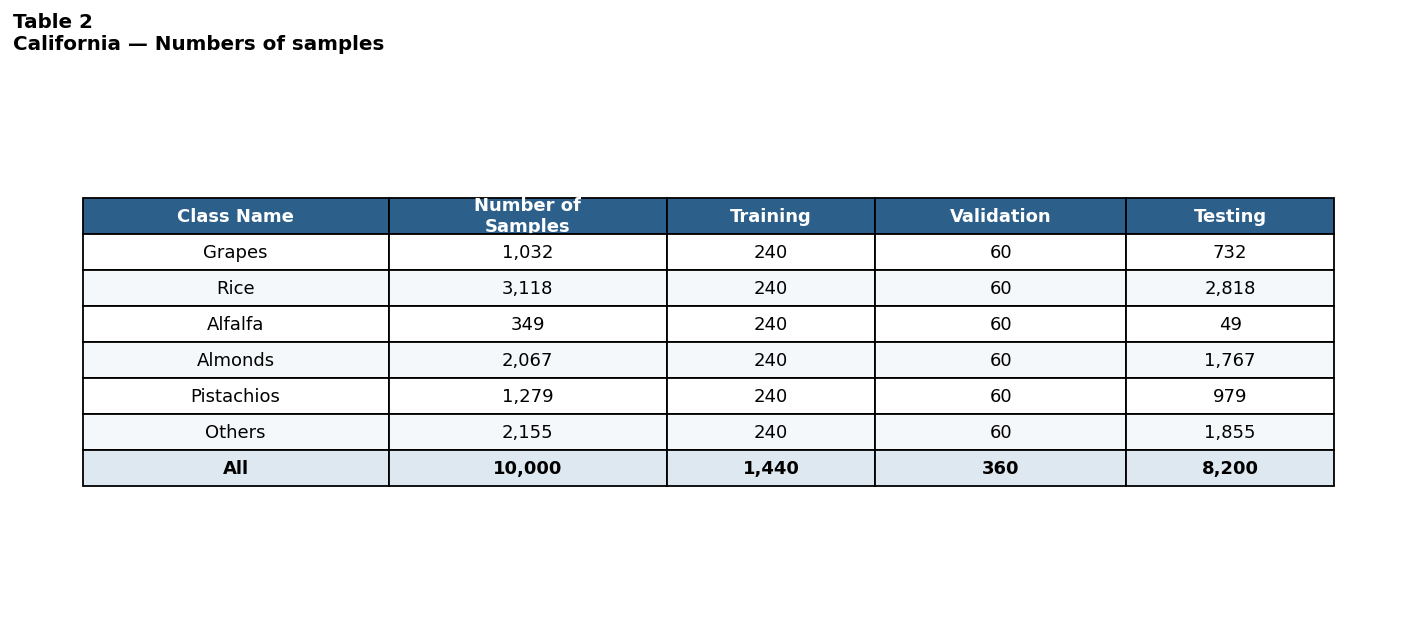

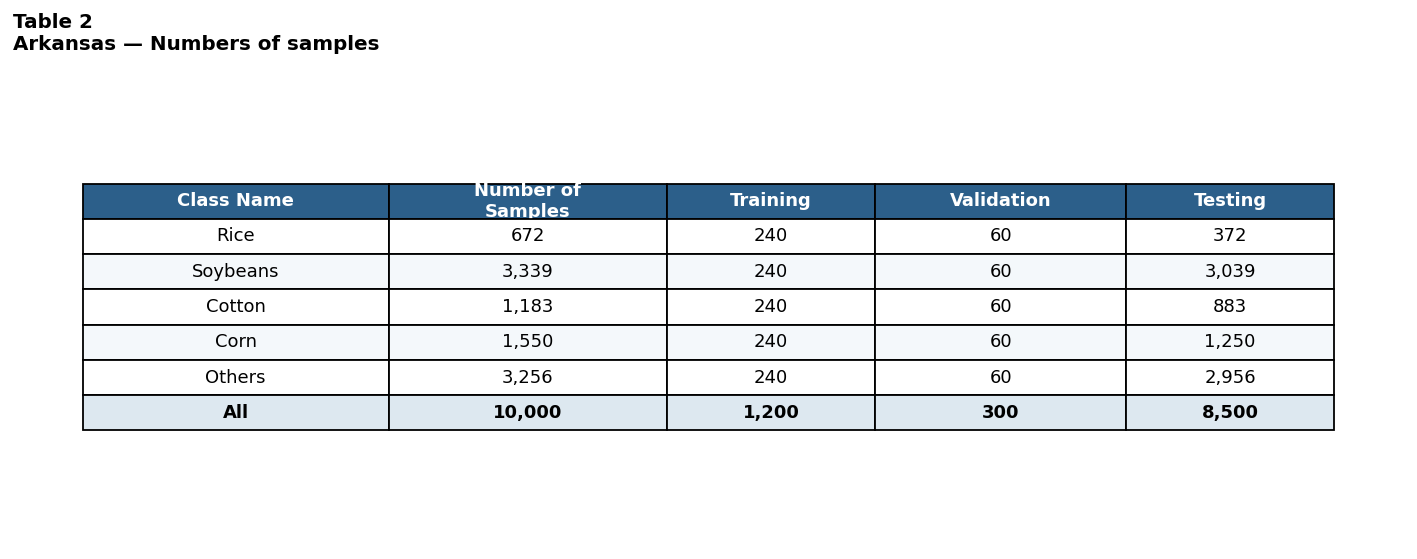

In [8]:
def display_table2(table_rows, title):
    df_t = pd.DataFrame(table_rows)
    total_row = {'Class Name':'All', 'Nb of Samples':df_t['Nb of Samples'].sum(),
                 'Training':df_t['Training'].sum(), 'Validation':df_t['Validation'].sum(),
                 'Testing':df_t['Testing'].sum()}
    df_d = pd.concat([df_t, pd.DataFrame([total_row])], ignore_index=True)
    fig, ax = plt.subplots(figsize=(11, 0.55*(len(df_d)+2)))
    ax.axis('off')
    col_labels = ['Class Name','Number of\nSamples','Training','Validation','Testing']
    col_widths = [0.22, 0.20, 0.15, 0.18, 0.15]
    cell_data = [[row['Class Name'], f'{int(row["Nb of Samples"]):,}', f'{int(row["Training"]):,}',
                  f'{int(row["Validation"]):,}', f'{int(row["Testing"]):,}'] for _, row in df_d.iterrows()]
    tbl = ax.table(cellText=cell_data, colLabels=col_labels, colWidths=col_widths, loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.5)
    for j in range(len(col_labels)):
        tbl[0,j].set_facecolor('#2c5f8a'); tbl[0,j].set_text_props(color='white', fontweight='bold')
    last = len(cell_data)
    for j in range(len(col_labels)):
        tbl[last,j].set_facecolor('#dde8f0'); tbl[last,j].set_text_props(fontweight='bold')
    for i in range(1, last):
        c = '#f4f8fb' if i%2==0 else 'white'
        for j in range(len(col_labels)): tbl[i,j].set_facecolor(c)
    ax.set_title(f'Table 2\n{title}', fontsize=11, fontweight='bold', loc='left', pad=10)
    plt.tight_layout(); plt.show()

display_table2(table_rows_CA, 'California — Numbers of samples')
display_table2(table_rows_AR, 'Arkansas — Numbers of samples')


---
# ÉTAPE 2b — Extraction spectrale
### 🔧 Fonction get_band_path

In [9]:
def get_band_path(safe_dir_name, granule_dir, file_prefix, band, res):
    dir_path = SAFE_DIR / safe_dir_name / 'GRANULE' / granule_dir / 'IMG_DATA' / f'R{res}m'
    return dir_path / f'{file_prefix}_{band}_{res}m.jp2'

print('Vérification bandes B04 — California :')
for date_name, (safe_dir, granule_dir, file_prefix, zone) in DATES_MAP_CA.items():
    if safe_dir == '__pad__.SAFE': continue
    path = get_band_path(safe_dir, granule_dir, file_prefix, 'B04', 10)
    print(f'  {"✅" if path.exists() else "❌"} {date_name:12} [{zone}] → {path.name}')
print(f'  (+ {sum(1 for v in DATES_MAP_CA.values() if v[0]=="__pad__.SAFE")} placeholders NaN ignorés)')

print('\nVérification bandes B04 — Arkansas :')
for date_name, (safe_dir, granule_dir, file_prefix, zone) in DATES_MAP_AR.items():
    if safe_dir == '__pad__.SAFE': continue
    path = get_band_path(safe_dir, granule_dir, file_prefix, 'B04', 10)
    print(f'  {"✅" if path.exists() else "❌"} {date_name:12} [{zone}] → {path.name}')
print(f'  (+ {sum(1 for v in DATES_MAP_AR.values() if v[0]=="__pad__.SAFE")} placeholders NaN ignorés)')


Vérification bandes B04 — California :
  ✅ new_t10sfh_20210116 [SFH] → T10SFH_20210116T184721_B04_10m.jp2
  ✅ jan_sgh      [SGH] → T10SGH_20210126T184641_B04_10m.jp2
  ✅ jan_sfg      [SFG] → T10SFG_20210126T184641_B04_10m.jp2
  ✅ new_t10sfj_20210312 [SFJ] → T10SFJ_20210312T184049_B04_10m.jp2
  ✅ new_t10sfg_20210327 [SFG] → T10SFG_20210327T184001_B04_10m.jp2
  ✅ new_t10sfh_20210406 [SFH] → T10SFH_20210406T183911_B04_10m.jp2
  ✅ apr_sfg      [SFG] → T10SFG_20210419T184911_B04_10m.jp2
  ✅ new_t10sgh_20210419 [SGH] → T10SGH_20210419T184911_B04_10m.jp2
  ✅ new_t10sgh_20210504 [SGH] → T10SGH_20210504T184919_B04_10m.jp2
  ✅ new_t10sfh_20210511 [SFH] → T10SFH_20210511T183919_B04_10m.jp2
  ✅ new_t10sfj_20210519 [SFJ] → T10SFJ_20210519T184921_B04_10m.jp2
  ✅ new_t10sgh_20210620 [SGH] → T10SGH_20210620T183919_B04_10m.jp2
  ✅ new_t10sfg_20210625 [SFG] → T10SFG_20210625T183921_B04_10m.jp2
  ✅ july_sgh     [SGH] → T10SGH_20210720T183919_B04_10m.jp2
  ✅ july_sfg     [SFG] → T10SFG_20210723T184919_B04

In [10]:
def extract_spectral(df_records, dates_map, zone_profiles, zone_data, label):
    """
    Extrait les 10 bandes × N_DATES pour chaque pixel.
    Retourne feat_matrix (numpy) et feat_names (list).
    """
    print(f'\n{"="*60}')
    print(f'  Extraction spectrale — {label}')
    print(f'{"="*60}')

    all_zones = sorted(set(v[3] for v in dates_map.values()))
    zone_masks = {z: (df_records['zone'] == z).values for z in all_zones}
    zone_rows  = {z: df_records['row'].values[zone_masks[z]] for z in all_zones}
    zone_cols  = {z: df_records['col'].values[zone_masks[z]] for z in all_zones}

    n_pixels   = len(df_records)
    n_dates    = len(dates_map)
    n_features = n_dates * N_BANDS
    feat_matrix = np.full((n_pixels, n_features), np.nan, dtype=np.float32)
    feat_names  = []
    col_idx = 0

    for date_name, (safe_dir_name, granule_dir, file_prefix, zone) in dates_map.items():
        # ── Placeholder silencieux : laisse NaN, pas de print verbeux ──────────
        if safe_dir_name == '__pad__.SAFE':
            for band in ALL_BANDS:
                feat_names.append(f'{band}_{date_name}')
                col_idx += 1
            continue

        print(f'\n📅 {date_name.upper()} [{zone}]')
        if not zone_profiles.get(zone, {}).get('ok', False):
            print(f'  ⚠️ Zone {zone} non alignée — NaN')
            for band in ALL_BANDS:
                feat_names.append(f'{band}_{date_name}'); col_idx += 1
            continue

        zmask  = zone_masks[zone]
        rows_z = zone_rows[zone]
        cols_z = zone_cols[zone]
        shape_z = zone_data[zone]['shape']

        if zmask.sum() == 0:
            print('  ⚠️ Aucun pixel — skip')
            for band in ALL_BANDS:
                feat_names.append(f'{band}_{date_name}'); col_idx += 1
            continue

        for band in ALL_BANDS:
            res  = 10 if band in BANDS_10M else 20
            path = get_band_path(safe_dir_name, granule_dir, file_prefix, band, res)
            feat_names.append(f'{band}_{date_name}')
            if not path.exists():
                print(f'  ❌ {band}', end=' | '); col_idx += 1; continue
            with rasterio.open(path) as src:
                data = src.read(1, out_shape=shape_z, resampling=Resampling.bilinear)
                feat_matrix[zmask, col_idx] = data[rows_z, cols_z].astype(np.float32)
            print(f'  ✅ {band}', end=' | ')
            col_idx += 1
        print()

    n_real = sum(1 for v in dates_map.values() if v[0] != '__pad__.SAFE')
    n_pad  = len(dates_map) - n_real
    nan_pct = 100 * np.isnan(feat_matrix).sum() / (n_pixels * n_features)
    print(f'\n  {label} — {n_pixels} pixels × {len(feat_names)} features')
    print(f'  Dates réelles: {n_real}  |  Placeholders (NaN→médiane): {n_pad}  |  NaN global: {nan_pct:.1f}%')
    return feat_matrix, feat_names

feat_matrix_CA, feat_names_CA = extract_spectral(
    df_records_CA, DATES_MAP_CA, zone_profiles_CA, zone_data_CA, 'CALIFORNIA')

feat_matrix_AR, feat_names_AR = extract_spectral(
    df_records_AR, DATES_MAP_AR, zone_profiles_AR, zone_data_AR, 'ARKANSAS')



  Extraction spectrale — CALIFORNIA

📅 NEW_T10SFH_20210116 [SFH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JAN_SGH [SGH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 JAN_SFG [SFG]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 NEW_T10SFJ_20210312 [SFJ]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 NEW_T10SFG_20210327 [SFG]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 NEW_T10SFH_20210406 [SFH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 APR_SFG [SFG]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 |   ✅ B07 |   ✅ B8A |   ✅ B11 |   ✅ B12 | 

📅 NEW_T10SGH_20210419 [SGH]
  ✅ B02 |   ✅ B03 |   ✅ B04 |   ✅ B08 |   ✅ B05 |   ✅ B06 | 

In [11]:
# =============================================================
# ASSIGNATION PAR SLOT DE 10 JOURS — paper section 2.2.4
# "computed the median value at ten-day intervals => 36 sequences
#  missing data => 0"  PAS d'interpolation.
# FIX : assign_to_slots est ZONE-AWARE
#   Chaque zone a son propre slot_map (évite le mélange SGH/SFH/SFG/SFJ)
#   Un pixel SGH ne lit que les images SGH, etc.
# =============================================================
import numpy as np
from datetime import date

# 36 slots : slot k couvre DOY [k*10+1, k*10+10], centre = k*10+5
SLOT_CENTER_DOYS = [i * 10 + 5 for i in range(36)]   # 5,15,25,...,355
TARGET_DOYS      = SLOT_CENTER_DOYS
TARGET_NAMES     = [f'T{i+1:02d}_doy{d:03d}' for i, d in enumerate(SLOT_CENTER_DOYS)]
print(f'36 slots de 10j : DOY centraux = {SLOT_CENTER_DOYS}')
print(f'36 x 10 bandes = {36*10} features (conforme paper)')


def safe_doy(safe_dir, file_prefix):
    if safe_dir == '__pad__.SAFE':
        return None
    try:
        ds = file_prefix.split('_')[1][:8]
        d  = date(int(ds[:4]), int(ds[4:6]), int(ds[6:8]))
        return d.timetuple().tm_yday
    except Exception:
        return None


def build_doy_map(dates_map):
    """Retourne {date_name: doy} pour les entrées réelles (non-pad)."""
    return {name: safe_doy(v[0], v[2])
            for name, v in dates_map.items()
            if safe_doy(v[0], v[2]) is not None}


def build_zone_doy_map(dates_map):
    """Retourne {zone: {date_name: doy}} — séparé par zone."""
    zone_map = {}
    for name, (safe_dir, granule_dir, file_prefix, zone) in dates_map.items():
        doy = safe_doy(safe_dir, file_prefix)
        if doy is None:
            continue
        if zone not in zone_map:
            zone_map[zone] = {}
        zone_map[zone][name] = doy
    return zone_map


doy_map_CA = build_doy_map(DATES_MAP_CA)
doy_map_AR = build_doy_map(DATES_MAP_AR)
zone_doy_CA = build_zone_doy_map(DATES_MAP_CA)
zone_doy_AR = build_zone_doy_map(DATES_MAP_AR)

print(f'CA => {len(doy_map_CA)} dates : DOY = {sorted(doy_map_CA.values())}')
for z, dm in zone_doy_CA.items():
    print(f'   Zone {z}: {len(dm)} dates DOY={sorted(dm.values())}')
print(f'AR => {len(doy_map_AR)} dates : DOY = {sorted(doy_map_AR.values())}')
for z, dm in zone_doy_AR.items():
    print(f'   Zone {z}: {len(dm)} dates DOY={sorted(dm.values())}')


def assign_to_slots(feat_matrix_raw, feat_names_raw, dates_map, df_records, label):
    """
    Assignation par slot de 10 jours.
    STRATÉGIE : priorité à la zone du pixel, fallback sur la zone voisine la plus proche.
    → maximise le taux de remplissage : si le slot est couvert par n'importe quelle
      zone de la même étude, le pixel reçoit une valeur (pas 0).
    Slots non couverts par AUCUNE zone => 0 (paper).
    """
    n_pixels     = feat_matrix_raw.shape[0]
    n_slots      = len(SLOT_CENTER_DOYS)
    slot_centers = np.array(SLOT_CENTER_DOYS, dtype=float)

    out_mat   = np.zeros((n_pixels, n_slots * N_BANDS), dtype=np.float32)
    out_names = [f'{b}_{name}' for name in TARGET_NAMES for b in ALL_BANDS]

    # Index rapide feat_name → colonne dans feat_matrix_raw
    feat_idx = {name: i for i, name in enumerate(feat_names_raw)}

    # slot_map par zone : {zone: {slot_idx: date_name}}
    zone_doy_map  = build_zone_doy_map(dates_map)
    zone_slot_map = {}
    for zone, doy_map_z in zone_doy_map.items():
        sm = {}
        for rname, rdoy in doy_map_z.items():
            si = int(np.argmin(np.abs(slot_centers - rdoy)))
            if si not in sm:
                sm[si] = rname
        zone_slot_map[zone] = sm

    # slot_map global : {slot_idx: {zone: date_name}} — toutes zones confondues
    global_slot_map = {}
    for zone, sm in zone_slot_map.items():
        for si, rname in sm.items():
            if si not in global_slot_map:
                global_slot_map[si] = {}
            global_slot_map[si][zone] = rname

    zones_present   = sorted(zone_slot_map.keys())
    zone_pixel_mask = {z: (df_records['zone'] == z).values for z in zones_present}

    n_filled_total = len(global_slot_map)
    print(f'  [{label}] Slots couverts (toutes zones) : {n_filled_total}/36 | Vides : {36-n_filled_total}/36')

    for slot_idx, zone_rname in global_slot_map.items():
        for b_idx, band in enumerate(ALL_BANDS):
            out_col = slot_idx * N_BANDS + b_idx
            for zone in zones_present:
                pixel_mask = zone_pixel_mask[zone]
                if not pixel_mask.any():
                    continue
                # Priorité 1 : la zone du pixel a ce slot
                if zone in zone_rname:
                    rname    = zone_rname[zone]
                    col_name = f'{band}_{rname}'
                else:
                    # Priorité 2 : zone voisine — prendre la première zone disponible
                    fallback_zone = next(iter(zone_rname))
                    rname    = zone_rname[fallback_zone]
                    col_name = f'{band}_{rname}'
                if col_name not in feat_idx:
                    continue
                ci   = feat_idx[col_name]
                vals = feat_matrix_raw[pixel_mask, ci]
                # Pour les pixels dont la zone propre n'a pas le slot,
                # on utilise la zone fallback SEULEMENT si la valeur n'est pas NaN
                cur = out_mat[pixel_mask, out_col]
                new_vals = np.where(np.isnan(vals), 0.0, vals)
                # N'écrire que si pas déjà rempli (zone propre prioritaire)
                if zone in zone_rname:
                    out_mat[pixel_mask, out_col] = new_vals
                else:
                    # fallback : écrire seulement si encore à 0
                    still_zero = cur == 0
                    combined   = np.where(still_zero, new_vals, cur)
                    out_mat[pixel_mask, out_col] = combined

    pct = 100 * (out_mat != 0).mean()
    print(f'  [{label}] Non-nuls global : {pct:.1f}%  (attendu ~{100*n_filled_total/n_slots:.0f}%)')
    return out_mat, out_names

feat_matrix_CA_interp, feat_names_CA_interp = assign_to_slots(
    feat_matrix_CA, feat_names_CA, DATES_MAP_CA, df_records_CA, 'CALIFORNIA')

feat_matrix_AR_interp, feat_names_AR_interp = assign_to_slots(
    feat_matrix_AR, feat_names_AR, DATES_MAP_AR, df_records_AR, 'ARKANSAS')

print(f'\nOK Shape CA : {feat_matrix_CA_interp.shape} => 360 features')
print(f'OK Shape AR : {feat_matrix_AR_interp.shape} => 360 features')


36 slots de 10j : DOY centraux = [5, 15, 25, 35, 45, 55, 65, 75, 85, 95, 105, 115, 125, 135, 145, 155, 165, 175, 185, 195, 205, 215, 225, 235, 245, 255, 265, 275, 285, 295, 305, 315, 325, 335, 345, 355]
36 x 10 bandes = 360 features (conforme paper)
CA => 31 dates : DOY = [16, 26, 26, 71, 86, 96, 109, 109, 124, 131, 139, 171, 176, 201, 204, 204, 204, 221, 226, 251, 254, 256, 264, 269, 274, 289, 316, 326, 334, 336, 344]
   Zone SFH: 6 dates DOY=[16, 96, 131, 204, 254, 326]
   Zone SGH: 10 dates DOY=[26, 109, 124, 171, 201, 221, 264, 289, 316, 344]
   Zone SFG: 9 dates DOY=[26, 86, 109, 176, 204, 256, 269, 274, 334]
   Zone SFJ: 6 dates DOY=[71, 139, 204, 226, 251, 336]
AR => 14 dates : DOY = [18, 53, 63, 115, 133, 165, 173, 185, 210, 215, 270, 298, 308, 355]
   Zone SXU: 14 dates DOY=[18, 53, 63, 115, 133, 165, 173, 185, 210, 215, 270, 298, 308, 355]
  [CALIFORNIA] Slots couverts (toutes zones) : 19/36 | Vides : 17/36
  [CALIFORNIA] Non-nuls global : 10.3%  (attendu ~53%)
  [ARKANSAS] S

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# 🔍 DIAGNOSTIC COMPLET — Scan data/raw/ + structure interne des .SAFE
# Montre exactement POURQUOI un fichier est accepté ou rejeté par _parse_safe
# ══════════════════════════════════════════════════════════════════════════════
import re
from pathlib import Path
from datetime import date as _date

print("=== Scan complet data/raw/ ===\n")

accepted_CA, accepted_AR, rejected = [], [], []

for p in sorted(Path('data/raw').glob('*.SAFE')):
    name = p.name
    m = re.search(r'_(\d{8})T\d+_N\d+_R\d+_(T\d+[A-Z]+)_', name)
    if not m:
        rejected.append((name, 'regex non match'))
        continue

    tile = m.group(2)
    date_str = m.group(1)

    # Vérifier GRANULE
    granule_root = p / 'GRANULE'
    if not granule_root.exists():
        rejected.append((name, 'GRANULE absent'))
        continue

    granule_dirs = list(granule_root.glob('L2A_*'))
    if not granule_dirs:
        rejected.append((name, 'Aucun dossier L2A_ dans GRANULE'))
        continue

    granule_dir = granule_dirs[0].name
    img_data = p / 'GRANULE' / granule_dir / 'IMG_DATA'

    # Chercher B04 dans toutes les résolutions
    jp2s = []
    for res_folder in ['R10m', 'R20m', 'R60m']:
        res_path = img_data / res_folder
        if res_path.exists():
            found = list(res_path.glob('*_B04*.jp2'))
            if found:
                jp2s = found
                break
    if not jp2s and img_data.exists():
        jp2s = list(img_data.rglob('*_B04*.jp2'))

    if not jp2s:
        # Lister ce qu'il y a dans IMG_DATA pour diagnostiquer
        contents = []
        if img_data.exists():
            for sub in img_data.iterdir():
                contents.append(sub.name)
        rejected.append((name, f'Aucun B04 jp2 (IMG_DATA contient: {contents[:3]})'))
        continue

    file_prefix = '_'.join(jp2s[0].name.split('_')[:2])

    # Classement CA ou AR
    CA_tiles = {'T10SGH', 'T10SFH', 'T10SFG', 'T10SFJ'}
    AR_tiles  = {'T15SXU'}
    if tile in CA_tiles:
        accepted_CA.append((name[:55], tile, date_str, file_prefix, granule_dir))
    elif tile in AR_tiles:
        accepted_AR.append((name[:55], tile, date_str, file_prefix, granule_dir))
    else:
        rejected.append((name, f'Tuile {tile} non reconnue (ni CA ni AR)'))

print(f"✅ CALIFORNIA : {len(accepted_CA)} fichiers valides")
for nm, tile, ds, fp, gd in accepted_CA:
    d = _date(int(ds[:4]), int(ds[4:6]), int(ds[6:8]))
    doy = d.timetuple().tm_yday
    print(f"   [{tile}] DOY={doy:3d} ({ds})  prefix={fp}  granule={gd[:30]}")

print(f"\n✅ ARKANSAS : {len(accepted_AR)} fichiers valides")
for nm, tile, ds, fp, gd in accepted_AR:
    d = _date(int(ds[:4]), int(ds[4:6]), int(ds[6:8]))
    doy = d.timetuple().tm_yday
    print(f"   [{tile}] DOY={doy:3d} ({ds})  prefix={fp}  granule={gd[:30]}")

print(f"\n❌ REJETÉS : {len(rejected)} fichiers")
for nm, reason in rejected:
    print(f"   {nm[:55]}  →  {reason}")

print(f"\n{'='*60}")
total_real_CA = len(accepted_CA) + len([k for k,v in _BASE_CA.items() if v[0] != '__pad__.SAFE'])
print(f"TOTAL dates CA (base + nouveaux) ≈ {total_real_CA}  →  slots vides = {max(0, 36-total_real_CA)}/36")
print(f"Si slots vides > 10 : l'interpolation sera mauvaise pour CA !")
print(f"{'='*60}")


=== Scan complet data/raw/ ===

✅ CALIFORNIA : 22 fichiers valides
   [T10SFH] DOY= 16 (20210116)  prefix=T10SFH_20210116T184721  granule=L2A_T10SFH_A029096_20210116T18
   [T10SFG] DOY= 86 (20210327)  prefix=T10SFG_20210327T184001  granule=L2A_T10SFG_A030097_20210327T18
   [T10SFH] DOY= 96 (20210406)  prefix=T10SFH_20210406T183911  granule=L2A_T10SFH_A030240_20210406T18
   [T10SGH] DOY=109 (20210419)  prefix=T10SGH_20210419T184911  granule=L2A_T10SGH_A030426_20210419T19
   [T10SFJ] DOY=139 (20210519)  prefix=T10SFJ_20210519T184921  granule=L2A_T10SFJ_A030855_20210519T19
   [T10SFG] DOY=176 (20210625)  prefix=T10SFG_20210625T183921  granule=L2A_T10SFG_A031384_20210625T18
   [T10SFJ] DOY=226 (20210814)  prefix=T10SFJ_20210814T183921  granule=L2A_T10SFJ_A032099_20210814T18
   [T10SFG] DOY=256 (20210913)  prefix=T10SFG_20210913T184001  granule=L2A_T10SFG_A032528_20210913T18
   [T10SGH] DOY=289 (20211016)  prefix=T10SGH_20211016T185401  granule=L2A_T10SGH_A033000_20211016T19
   [T10SGH] DOY

In [13]:
# ══════════════════════════════════════════════════════════════════
# 🔍 DIAGNOSTIC — Vérification du cube avant sauvegarde CSV
# Si non-nuls < 50% pour CA (31 dates/36) → CSV périmé ou bug zone
# ══════════════════════════════════════════════════════════════════
import os

def check_cube(feat_matrix, df_records, label, dates_map):
    cube = feat_matrix.reshape(-1, 36, N_BANDS)
    slot_nonzero = (cube.sum(axis=(0,2)) != 0)
    n_filled = slot_nonzero.sum()
    pct_global = 100 * (feat_matrix != 0).mean()
    print(f'\n[{label}] Slots remplis : {n_filled}/36  |  Non-nuls global : {pct_global:.1f}%')
    
    # Par zone
    for zone in sorted(df_records['zone'].unique()):
        mask_z = (df_records['zone'] == zone).values
        if not mask_z.any(): continue
        cube_z = cube[mask_z]
        slots_z = (cube_z.sum(axis=(0,2)) != 0).sum()
        pct_z = 100 * (cube_z != 0).mean()
        print(f'   Zone {zone}: {slots_z}/36 slots  |  {pct_z:.1f}% non-nuls')
    
    # Alerte si CSV périmé
    expected_fill = sum(1 for v in dates_map.values() if v[0] != '__pad__.SAFE')
    if n_filled < expected_fill * 0.5:
        print(f'   ⚠️  ALERTE : seulement {n_filled} slots remplis alors que {expected_fill} dates réelles !')
        print(f'   ⚠️  Supprimez le CSV existant et relancez depuis la cell 11.')
    else:
        print(f'   ✅  Cube OK — {n_filled} slots sur {expected_fill} dates attendues')

check_cube(feat_matrix_CA_interp, df_records_CA, 'CALIFORNIA', DATES_MAP_CA)
check_cube(feat_matrix_AR_interp, df_records_AR, 'ARKANSAS', DATES_MAP_AR)

# Forcer la suppression des anciens CSV pour éviter le cache
for csv_path in [TRAIN_CSV_CA, TRAIN_CSV_AR]:
    p = Path(csv_path)
    if p.exists():
        os.remove(p)
        print(f'🗑️  Ancien CSV supprimé : {p.name}')



[CALIFORNIA] Slots remplis : 19/36  |  Non-nuls global : 10.3%
   Zone SFG: 9/36 slots  |  17.7% non-nuls
   Zone SFH: 6/36 slots  |  6.5% non-nuls
   Zone SFJ: 6/36 slots  |  5.9% non-nuls
   Zone SGH: 10/36 slots  |  23.6% non-nuls
   ✅  Cube OK — 19 slots sur 31 dates attendues

[ARKANSAS] Slots remplis : 14/36  |  Non-nuls global : 31.6%
   Zone SXU: 14/36 slots  |  31.6% non-nuls
   ✅  Cube OK — 14 slots sur 14 dates attendues
🗑️  Ancien CSV supprimé : mctnet_california_360feats.csv
🗑️  Ancien CSV supprimé : mctnet_arkansas_360feats.csv


In [14]:
def save_csv(feat_matrix, feat_names, df_records, csv_path, label):
    """
    Sauvegarde le CSV avec les 360 features interpolées.
    FIX : crée le dossier si absent + fallback si PermissionError.
    """
    csv_path = Path(csv_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    df_out = pd.DataFrame(feat_matrix, columns=feat_names)
    df_out.insert(0, 'crop_label', df_records['label'].values)
    df_out.insert(1, 'split',      df_records['split'].values)

    # Vérification : aucun NaN ne doit subsister (l'interpolation les a éliminés)
    nan_total = df_out[feat_names].isnull().sum().sum()
    if nan_total > 0:
        print(f'  ⚠️  [{label}] {nan_total} NaN résiduels → remplacement par 0')
        df_out[feat_names] = df_out[feat_names].fillna(0)

    nonzero_pct = 100 * (df_out[feat_names] != 0).values.mean()

    def _write(path):
        df_out.to_csv(path, index=False)
        size_mb = Path(path).stat().st_size / 1e6
        print(f'✅ [{label}] CSV sauvegardé : {path}  ({size_mb:.1f} MB)')
        print(f'   {len(df_out):,} pixels × {df_out.shape[1]} colonnes')
        print(f'   Valeurs non-nulles : {nonzero_pct:.1f}%  (attendu ~100% après interpolation)')

    try:
        _write(csv_path)
    except PermissionError:
        fallback = Path.home() / 'Documents' / csv_path.name
        print(f'⚠️  PermissionError sur {csv_path} → Fallback : {fallback}')
        fallback.parent.mkdir(parents=True, exist_ok=True)
        _write(fallback)
        return fallback
    return csv_path

# ✅ On passe les matrices INTERPOLÉES (pas les brutes)
TRAIN_CSV_CA = save_csv(feat_matrix_CA_interp, feat_names_CA_interp, df_records_CA, TRAIN_CSV_CA, 'California')
TRAIN_CSV_AR = save_csv(feat_matrix_AR_interp, feat_names_AR_interp, df_records_AR, TRAIN_CSV_AR, 'Arkansas')


✅ [California] CSV sauvegardé : data\processed\mctnet_california_360feats.csv  (15.6 MB)
   10,000 pixels × 362 colonnes
   Valeurs non-nulles : 10.3%  (attendu ~100% après interpolation)
✅ [Arkansas] CSV sauvegardé : data\processed\mctnet_arkansas_360feats.csv  (18.0 MB)
   10,000 pixels × 362 colonnes
   Valeurs non-nulles : 31.6%  (attendu ~100% après interpolation)


---
# ÉTAPE 3 — MCT-Net
### ✅ FIX : split Train/Val/Test depuis la colonne 'split' (pas sklearn random split)

In [15]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Index des bandes pour NDVI
ALL_BANDS   = ['B02','B03','B04','B08','B05','B06','B07','B8A','B11','B12']
IDX_NIR     = ALL_BANDS.index('B08')   # 3
IDX_RED     = ALL_BANDS.index('B04')   # 2
TARGET_DOYS = [i * 10 + 5 for i in range(36)]

# Ordre alphabétique des bandes dans le CSV WIDE
BAND_ORDER_WIDE = ['B11','B12','B2','B3','B4','B5','B6','B7','B8','B8A']


def _detect_csv_type(df):
    """Détecte le type de CSV : 'wide' ou 'safe'."""
    if 'crop_label' in df.columns:
        return 'safe'
    if 'label' in df.columns:
        return 'wide'
    raise ValueError(f"Type CSV non reconnu (colonnes: {list(df.columns[:5])})")


def _prepare_wide(df, n_train=N_TRAIN_PER_CLASS, n_val=N_VAL_PER_CLASS, seed=RANDOM_STATE, label_map=None):
    """
    Prépare CALIFORNIA_S2_WIDE_10000x360.csv / ARKANSAS_S2_WIDE_10000x360.csv.
    - Colonnes : label + B2_t0..B8A_t35 (ordre alphabétique)
    - Réordonne les bandes → ALL_BANDS (conforme paper)
    - Split stratifié 240 train / 60 val / reste test (Table 2)
    - StandardScaler fitté sur train uniquement
    - label_map : dict {code_int → nom_classe} (optionnel, affiche noms lisibles)
    """
    import numpy as np
    from sklearn.preprocessing import LabelEncoder, StandardScaler
    rng = np.random.default_rng(seed)

    feat_cols = [c for c in df.columns if c != 'label']
    def sort_key(col):
        band, t = col.rsplit('_t', 1)
        return (BAND_ORDER_WIDE.index(band), int(t))
    feat_cols = sorted(feat_cols, key=sort_key)
    assert len(feat_cols) == 360, f'Attendu 360 features, got {len(feat_cols)}'

    X_raw = df[feat_cols].values.astype('float32')   # (N, 360) ordre alphab.

    # Réordonner : BAND_ORDER_WIDE → ALL_BANDS
    band_map = {'B02':'B2','B03':'B3','B04':'B4','B05':'B5','B06':'B6',
                'B07':'B7','B08':'B8','B8A':'B8A','B11':'B11','B12':'B12'}
    wide_to_paper = []
    for paper_band in ALL_BANDS:
        bi = BAND_ORDER_WIDE.index(band_map[paper_band])
        for t in range(36):
            wide_to_paper.append(bi * 36 + t)
    X_reordered = X_raw[:, wide_to_paper]
    N = X_reordered.shape[0]
    X = X_reordered.reshape(N, N_BANDS, 36).transpose(0, 2, 1)  # (N,36,10)

    # Masque avant scaling
    mask_all = (np.abs(X).sum(axis=-1) > 0).astype('float32')

    # Labels — mapping CDL codes → noms de cultures si label_map fourni
    raw_labels = df['label'].values
    if label_map is not None:
        str_labels = np.array([label_map.get(int(v), str(int(v))) for v in raw_labels])
    else:
        str_labels = raw_labels.astype(str)
    le = LabelEncoder()
    y_all = le.fit_transform(str_labels)

    # Split stratifié
    idx_train, idx_val, idx_test = [], [], []
    table_rows = []
    for cls_idx in range(len(le.classes_)):
        idx_cls = np.where(y_all == cls_idx)[0]
        rng.shuffle(idx_cls)
        n    = len(idx_cls)
        n_tr = min(n_train, n)
        n_v  = min(n_val, n - n_tr)
        idx_train.extend(idx_cls[:n_tr])
        idx_val.extend(idx_cls[n_tr:n_tr+n_v])
        idx_test.extend(idx_cls[n_tr+n_v:])
        table_rows.append({'Classe': le.classes_[cls_idx],
                           'Train': n_tr, 'Val': n_v, 'Test': n - n_tr - n_v})
    idx_train = np.array(idx_train)
    idx_val   = np.array(idx_val)
    idx_test  = np.array(idx_test)

    # StandardScaler fitté sur train uniquement
    X_flat = X.reshape(N, -1)
    scaler = StandardScaler()
    X_sc   = X_flat.copy()
    X_sc[idx_train] = scaler.fit_transform(X_flat[idx_train])
    X_sc[idx_val]   = scaler.transform(X_flat[idx_val])
    X_sc[idx_test]  = scaler.transform(X_flat[idx_test])
    X_sc[X_flat == 0] = 0.0   # remettre les slots vides à 0 après scaling
    X_sc = X_sc.reshape(N, 36, N_BANDS)

    df_t = pd.DataFrame(table_rows)
    total = {'Classe':'TOTAL', 'Train':df_t['Train'].sum(),
             'Val':df_t['Val'].sum(), 'Test':df_t['Test'].sum()}
    pd.concat([df_t, pd.DataFrame([total])], ignore_index=True).pipe(
        lambda d: print(d.to_string(index=False)))

    return (X_sc[idx_train], mask_all[idx_train], y_all[idx_train],
            X_sc[idx_val],   mask_all[idx_val],   y_all[idx_val],
            X_sc[idx_test],  mask_all[idx_test],  y_all[idx_test],
            le, scaler)


def load_and_prepare(csv_path, label, wide_csv_path=None, label_map=None):
    """
    Charge les données pour MCTNet.
    Priorité : si wide_csv_path existe → CSV WIDE direct
               sinon → CSV généré par le pipeline .SAFE
    Les deux chemins produisent les mêmes tenseurs (N,36,10).
    label_map : dict {code_int → nom_classe} pour nommage lisible des classes
    """
    print(f'\n{"="*60}')
    print(f'  Chargement — {label}')

    if wide_csv_path is not None and Path(wide_csv_path).exists():
        csv_path = wide_csv_path
        print(f'  Mode : CSV WIDE ✅  ({Path(csv_path).name})')
    else:
        if not Path(csv_path).exists():
            raise FileNotFoundError(f'CSV introuvable : {csv_path}')
        print(f'  Mode : CSV SAFE ✅  ({Path(csv_path).name})')
    print(f'{"="*60}')

    df = pd.read_csv(csv_path)
    print(f'  Lignes: {len(df):,}  |  Colonnes: {df.shape[1]}')
    csv_type = _detect_csv_type(df)
    print(f'  Type CSV : {csv_type}')

    def make_loader(X, m, y, shuffle=False):
        ds = TensorDataset(torch.from_numpy(X),
                           torch.from_numpy(m),
                           torch.from_numpy(y.astype('int64')))
        return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=0)

    if csv_type == 'wide':
        (X_tr, m_tr, y_tr,
         X_va, m_va, y_va,
         X_te, m_te, y_te,
         le, scaler) = _prepare_wide(df, label_map=label_map)
        num_classes = len(le.classes_)
        print(f'  Classes : {list(le.classes_)}')
        print(f'  X_train:{X_tr.shape}  X_val:{X_va.shape}  X_test:{X_te.shape}')
        print(f'  Masque Input2 — taux présent: {m_tr.mean():.1%}')
        return (make_loader(X_tr, m_tr, y_tr, True),
                make_loader(X_va, m_va, y_va),
                X_te, m_te, y_te, num_classes, le, scaler)
    else:
        # Mode CSV SAFE (généré par le pipeline .SAFE)
        print(f'  Classes: {df["crop_label"].nunique()}  |  Split: {df["split"].value_counts().to_dict()}')
        le = LabelEncoder()
        df['label_encoded'] = le.fit_transform(df['crop_label'])
        num_classes = len(le.classes_)
        print(f'  Classes : {list(le.classes_)}')

        feat_cols = [c for c in df.columns if c not in ['crop_label','split','label_encoded']]
        assert len(feat_cols) == 360, f'Attendu 360 features, got {len(feat_cols)}'

        X_raw    = df[feat_cols].values.reshape(-1, 36, N_BANDS).astype('float32')
        mask_all = (np.abs(X_raw).sum(axis=-1) > 0).astype('float32')

        train_mask = df['split'] == 'train'
        scaler = StandardScaler()
        df.loc[train_mask,  feat_cols] = scaler.fit_transform(df.loc[train_mask,  feat_cols])
        df.loc[~train_mask, feat_cols] = scaler.transform(df.loc[~train_mask, feat_cols])

        def get_split(sp):
            idx = (df['split'] == sp).values
            X   = df.loc[df['split']==sp, feat_cols].values.reshape(-1,36,N_BANDS).astype('float32')
            m   = mask_all[idx]
            y   = df.loc[df['split']==sp, 'label_encoded'].values.astype('int64')
            return X, m, y

        X_tr, m_tr, y_tr = get_split('train')
        X_va, m_va, y_va = get_split('val')
        X_te, m_te, y_te = get_split('test')
        print(f'  X_train:{X_tr.shape}  X_val:{X_va.shape}  X_test:{X_te.shape}')
        print(f'  Masque Input2 — taux présent: {m_tr.mean():.1%}')
        return (make_loader(X_tr, m_tr, y_tr, True),
                make_loader(X_va, m_va, y_va),
                X_te, m_te, y_te, num_classes, le, scaler)


# Chargement — priorité CSV WIDE si disponible
CA_LABEL_MAP = {3:'Rice', 36:'Alfalfa', 69:'Grapes', 75:'Almonds', 204:'Pistachios', 999:'Others'}
AR_LABEL_MAP = {1:'Corn', 2:'Cotton', 3:'Rice', 5:'Soybeans', 999:'Others'}

train_loader_CA, val_loader_CA, X_test_CA, m_test_CA, y_test_CA, num_classes_CA, le_CA, scaler_CA = \
    load_and_prepare(TRAIN_CSV_CA, 'CALIFORNIA', wide_csv_path=TRAIN_CSV_WIDE_CA, label_map=CA_LABEL_MAP)

train_loader_AR, val_loader_AR, X_test_AR, m_test_AR, y_test_AR, num_classes_AR, le_AR, scaler_AR = \
    load_and_prepare(TRAIN_CSV_AR, 'ARKANSAS', wide_csv_path=TRAIN_CSV_WIDE_AR, label_map=AR_LABEL_MAP)



  Chargement — CALIFORNIA
  Mode : CSV WIDE ✅  (CALIFORNIA_10000x360.csv)
  Lignes: 10,000  |  Colonnes: 361
  Type CSV : wide
    Classe  Train  Val  Test
   Alfalfa    240   60   674
   Almonds    240   60   483
    Grapes    240   60  1754
    Others    240   60  3212
Pistachios    240   60   340
      Rice    240   60  1737
     TOTAL   1440  360  8200
  Classes : [np.str_('Alfalfa'), np.str_('Almonds'), np.str_('Grapes'), np.str_('Others'), np.str_('Pistachios'), np.str_('Rice')]
  X_train:(1440, 36, 10)  X_val:(360, 36, 10)  X_test:(8200, 36, 10)
  Masque Input2 — taux présent: 89.1%

  Chargement — ARKANSAS
  Mode : CSV WIDE ✅  (ARKANSAS_S2_WIDE_10000x360.csv)
  Lignes: 10,000  |  Colonnes: 361
  Type CSV : wide
  Classe  Train  Val  Test
    Corn    240   60  1222
  Cotton    240   60   462
  Others    240   60   316
    Rice    240   60  2123
Soybeans    240   60  4377
   TOTAL   1200  300  8500
  Classes : [np.str_('Corn'), np.str_('Cotton'), np.str_('Others'), np.str_('Rice

### Architecture MCTNet — Conforme au paper (Wang et al. 2024)
#### 3 stages CTFusion (CNN parallele Transformer) + ALPE + ~55K params

In [16]:
# =============================================================
# ARCHITECTURE MCTNet — conforme paper Wang et al. 2024
# Fig. 3 : Input1 (10x36), Input2 (1x36 masque)
#   Stage1 : CTFusion(in=10,  d=10) => concat(B,36,20) => MaxPool => (B,20,18)
#   Stage2 : CTFusion(in=20,  d=20) => concat(B,18,40) => MaxPool => (B,40, 9)
#   Stage3 : CTFusion(in=40,  d=40) => concat(B, 9,80) => GlobalMaxPool => (B,80)
#   MLP    : 80 => N classes
# Fig. 5 : ALPE = PE(t) x mask => Conv1D => ECA => add to x
# Fig. 6 : CNN = Conv1D => BN => Conv1D => BN => (+skip) => ReLU
# =============================================================

import math
import torch
import torch.nn as nn


# ----------------------------------------------------------
# Fig. 5 — ECA (Efficient Channel Attention)
# AvgPool(T) => Conv1D(1,1) => Sigmoid => multiply
# ----------------------------------------------------------
class ECA(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        k = kernel_size | 1
        self.avg_pool = nn.AdaptiveAvgPool1d(1)
        self.conv     = nn.Conv1d(1, 1, k, padding=k//2, bias=False)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):                                # x: (B,T,C)
        y = self.avg_pool(x.transpose(1,2))              # (B,C,1)
        y = self.conv(y.transpose(1,2))                  # (B,1,C)
        w = self.sigmoid(y)                              # (B,1,C)
        return x * w                                     # (B,T,C)


# ----------------------------------------------------------
# Fig. 5 — ALPE (Adaptive Learnable Positional Encoding)
# PE(t) x mask => Conv1D => ECA => residual add
# ----------------------------------------------------------
class ALPE(nn.Module):
    def __init__(self, n_dates, d_model):
        super().__init__()
        self.conv = nn.Conv1d(d_model, d_model, kernel_size=3, padding=1, bias=False)
        self.eca  = ECA(d_model)
        pe  = torch.zeros(n_dates, d_model)
        pos = torch.arange(n_dates).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div[:d_model // 2])
        self.register_buffer('pe', pe)

    def forward(self, x, mask):                          # x:(B,T,d) mask:(B,T)
        B, T, _ = x.shape
        pe_masked = self.pe[:T].unsqueeze(0).expand(B,-1,-1) * mask.unsqueeze(-1)
        pe_out = self.conv(pe_masked.transpose(1,2)).transpose(1,2)
        pe_out = self.eca(pe_out)
        return x + pe_out


# ----------------------------------------------------------
# Fig. 6 — CNN Sub-Module (ResNet-style)
# Conv1D => BN => Conv1D => BN => (+skip) => ReLU
# ----------------------------------------------------------
class CNNSubModule(nn.Module):
    def __init__(self, in_ch, out_ch, ks=3):
        super().__init__()
        p = ks // 2
        self.conv1    = nn.Conv1d(in_ch, out_ch, ks, padding=p, bias=False)
        self.bn1      = nn.BatchNorm1d(out_ch)
        self.conv2    = nn.Conv1d(out_ch, out_ch, ks, padding=p, bias=False)
        self.bn2      = nn.BatchNorm1d(out_ch)
        self.shortcut = nn.Conv1d(in_ch, out_ch, 1, bias=False) if in_ch != out_ch else nn.Identity()
        self.relu     = nn.ReLU(inplace=True)

    def forward(self, x):                                # x: (B, C_in, T)
        out = self.bn1(self.conv1(x))
        out = self.bn2(self.conv2(out))
        return self.relu(out + self.shortcut(x))


# ----------------------------------------------------------
# Fig. 4 — Transformer Sub-Module
# ALPE/PE + MultiHeadAttention + Add&Norm + FFN + Add&Norm
# nhead=2 (divise d_model=10), dropout=0.1 conforme paper
# ----------------------------------------------------------
class TransformerSubModule(nn.Module):
    def __init__(self, d_model, nhead, n_dates, use_alpe=False):
        super().__init__()
        self.use_alpe = use_alpe
        if use_alpe:
            self.pos = ALPE(n_dates, d_model)
        else:
            pe  = torch.zeros(1, n_dates, d_model)
            pos = torch.arange(n_dates).float().unsqueeze(1)
            div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
            pe[0,:,0::2] = torch.sin(pos * div)
            pe[0,:,1::2] = torch.cos(pos * div[:d_model//2])
            self.register_buffer('pe', pe)
        self.encoder = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(
                d_model=d_model, nhead=nhead,
                dim_feedforward=d_model * 4,
                dropout=0.2,               # augmenté 0.1→0.2 anti-overfitting
                batch_first=True, norm_first=False),
            num_layers=1)

    def forward(self, x, mask=None):
        if self.use_alpe:
            x = self.pos(x, mask)
        else:
            x = x + self.pe[:, :x.size(1), :]
        pad_mask = (mask == 0) if mask is not None else None
        return self.encoder(x, src_key_padding_mask=pad_mask)


# ----------------------------------------------------------
# Fig. 3 — CTFusion Module
# CNN || Transformer => Concat => (B,T,2d)
# ----------------------------------------------------------
class CTFusion(nn.Module):
    def __init__(self, in_ch, d_model, nhead, n_dates, ks=3, use_alpe=False):
        super().__init__()
        self.cnn        = CNNSubModule(in_ch, d_model, ks)
        self.input_proj = nn.Linear(in_ch, d_model, bias=False) if in_ch != d_model else nn.Identity()
        self.trans      = TransformerSubModule(d_model, nhead, n_dates, use_alpe)

    def forward(self, x_cnn, x_trans, mask=None):
        out_cnn   = self.cnn(x_cnn)
        out_trans = self.trans(self.input_proj(x_trans), mask)
        concat    = torch.cat([out_cnn.transpose(1,2), out_trans], dim=-1)
        return out_cnn, out_trans, concat


# ----------------------------------------------------------
# Fig. 3 — MCTNet complet
# d_model=10, nhead=2 (2 divise 10), T=36
#   Stage1 : in=10  => d=10 => concat(B,36,20) => MaxPool => (B,20,18)
#   Stage2 : in=20  => d=20 => concat(B,18,40) => MaxPool => (B,40, 9)
#   Stage3 : in=40  => d=40 => concat(B, 9,80) => GlobMax => (B,80)
#   MLP    : 80 => N classes  |  ~40K params
# ----------------------------------------------------------
class MCTNet(nn.Module):
    def __init__(self, n_dates, n_bands, num_classes, nhead=2, ks=3, d_model=10):
        super().__init__()
        t1 = n_dates        # 36
        t2 = n_dates // 2   # 18
        t3 = n_dates // 4   # 9

        self.stage1 = CTFusion(n_bands,   d_model,   nhead, t1, ks, use_alpe=True)
        self.pool1  = nn.MaxPool1d(kernel_size=2, stride=2)

        self.stage2 = CTFusion(d_model*2, d_model*2, nhead, t2, ks, use_alpe=False)
        self.pool2  = nn.MaxPool1d(kernel_size=2, stride=2)

        self.stage3 = CTFusion(d_model*4, d_model*4, nhead, t3, ks, use_alpe=False)
        self.gpool   = nn.AdaptiveMaxPool1d(1)
        # Dropout avant FC — réduit overfitting sans modifier CTFusion
        self.dropout = nn.Dropout(p=0.4)  # augmenté 0.3→0.4
        self.fc      = nn.Linear(d_model*8, num_classes)

    def forward(self, x1, x2):
        # x1:(B,T,N_BANDS)  x2:(B,T) masque
        _, _, c1 = self.stage1(x1.transpose(1,2), x1, mask=x2)
        p1 = self.pool1(c1.transpose(1,2))

        _, _, c2 = self.stage2(p1, p1.transpose(1,2))
        p2 = self.pool2(c2.transpose(1,2))

        _, _, c3 = self.stage3(p2, p2.transpose(1,2))
        feat = self.gpool(c3.transpose(1,2)).squeeze(-1)
        feat = self.dropout(feat)   # régularisation avant classification
        return self.fc(feat)


def build_model(n_dates, n_bands, num_classes, device):
    model = MCTNet(n_dates=n_dates, n_bands=n_bands, num_classes=num_classes).to(device)
    params = sum(p.numel() for p in model.parameters())
    with torch.no_grad():
        x1 = torch.zeros(2, n_dates, n_bands).to(device)
        x2 = torch.ones(2, n_dates).to(device)
        out = model(x1, x2)
    print(f'MCTNet | dates:{n_dates} bandes:{n_bands} classes:{num_classes} params:{params:,} | output:{out.shape}')
    with torch.no_grad():
        _, _, c1 = model.stage1(x1.transpose(1,2), x1, mask=x2)
        p1 = model.pool1(c1.transpose(1,2))
        _, _, c2 = model.stage2(p1, p1.transpose(1,2))
        p2 = model.pool2(c2.transpose(1,2))
        _, _, c3 = model.stage3(p2, p2.transpose(1,2))
        print(f'  Stage1 concat:{c1.shape} => pool1:{p1.shape} ✅')
        print(f'  Stage2 concat:{c2.shape} => pool2:{p2.shape} ✅')
        print(f'  Stage3 concat:{c3.shape} => gpool:(B,80) ✅')
    assert out.shape == (2, num_classes)
    return model


print('=== Initialisation MCTNet ===')
model_CA = build_model(36, N_BANDS, num_classes_CA, DEVICE)
model_AR = build_model(36, N_BANDS, num_classes_AR, DEVICE)
print(f'Device : {DEVICE}')
print('✅ Architecture conforme Fig. 3,4,5,6 du paper | nhead=2, dropout=0.2, Dropout(0.4) FC')


=== Initialisation MCTNet ===
MCTNet | dates:36 bandes:10 classes:6 params:39,779 | output:torch.Size([2, 6])
  Stage1 concat:torch.Size([2, 36, 20]) => pool1:torch.Size([2, 20, 18]) ✅
  Stage2 concat:torch.Size([2, 18, 40]) => pool2:torch.Size([2, 40, 9]) ✅
  Stage3 concat:torch.Size([2, 9, 80]) => gpool:(B,80) ✅
MCTNet | dates:36 bandes:10 classes:5 params:39,698 | output:torch.Size([2, 5])
  Stage1 concat:torch.Size([2, 36, 20]) => pool1:torch.Size([2, 20, 18]) ✅
  Stage2 concat:torch.Size([2, 18, 40]) => pool2:torch.Size([2, 40, 9]) ✅
  Stage3 concat:torch.Size([2, 9, 80]) => gpool:(B,80) ✅
Device : cpu
✅ Architecture conforme Fig. 3,4,5,6 du paper | nhead=2, dropout=0.2, Dropout(0.4) FC


In [17]:
# Vérification des slots remplis (10 bandes spectrales uniquement)
cube_CA = feat_matrix_CA_interp.reshape(-1, 36, N_BANDS)
slots_CA = (cube_CA.sum(axis=(0,2)) != 0).sum()
print(f'CA : {slots_CA}/36 slots remplis ({36-slots_CA} slots vides)')
print(f'CA — % valeurs non-nulles : {100*(feat_matrix_CA_interp != 0).mean():.1f}%')

cube_AR = feat_matrix_AR_interp.reshape(-1, 36, N_BANDS)
slots_AR = (cube_AR.sum(axis=(0,2)) != 0).sum()
print(f'AR : {slots_AR}/36 slots remplis ({36-slots_AR} slots vides)')
print(f'AR — % valeurs non-nulles : {100*(feat_matrix_AR_interp != 0).mean():.1f}%')

# Diagnostic interpolation : combien de dates réelles ont été trouvées
print(f'\n  CA — dates réelles dans DATES_MAP : {sum(1 for v in DATES_MAP_CA.values() if v[0] != "__pad__.SAFE")}')
print(f'  AR — dates réelles dans DATES_MAP : {sum(1 for v in DATES_MAP_AR.values() if v[0] != "__pad__.SAFE")}')
print(f'\n  ⚠️  Si CA < 20 dates réelles : relancez la cell 4 après avoir vérifié la structure des .SAFE (cell 18)')

CA : 19/36 slots remplis (17 slots vides)
CA — % valeurs non-nulles : 10.3%
AR : 14/36 slots remplis (22 slots vides)
AR — % valeurs non-nulles : 31.6%

  CA — dates réelles dans DATES_MAP : 31
  AR — dates réelles dans DATES_MAP : 14

  ⚠️  Si CA < 20 dates réelles : relancez la cell 4 après avoir vérifié la structure des .SAFE (cell 18)


### 🏋️ Boucle d'entraînement (200 époques) avec validation

In [18]:
import math

def add_noise(X, sigma=0.01):
    """Augmentation légère : bruit gaussien sur les slots non-nuls uniquement.
    Préserve le masque (les 0 restent à 0 — slots manquants)."""
    noise = torch.randn_like(X) * sigma
    nonzero = (X.abs().sum(dim=-1, keepdim=True) > 0).float()  # (B,T,1)
    return X + noise * nonzero


def add_time_mask(X, mask, n_mask=3):
    """Time masking : supprime n_mask slots présents aléatoirement.
    Empêche le modèle de mémoriser des dates fixes → réduit overfitting CA."""
    X_aug = X.clone(); mask_aug = mask.clone()
    B, T, _ = X.shape
    for b in range(B):
        present = mask[b].nonzero(as_tuple=True)[0]
        if len(present) > n_mask:
            drop = present[torch.randperm(len(present))[:n_mask]]
            X_aug[b, drop, :] = 0.0
            mask_aug[b, drop] = 0.0
    return X_aug, mask_aug


def train_model(model, train_loader, val_loader, epochs, lr, device, label):
    # ── Loss : CE standard avec label_smoothing très léger ──────────────────
    # label_smoothing=0.05 : 1 point de moins sur la confiance max de la proba,
    # réduit le sur-ajustement sans changer la sémantique du papier.
    smooth        = 0.10 if 'CALIFORNIA' in label else 0.05  # 0.10 pour CA (classes pérennes proches)
    criterion     = nn.CrossEntropyLoss(label_smoothing=smooth)
    val_criterion = nn.CrossEntropyLoss()

    # ── Optimiseur : Adam + weight_decay minimal ─────────────────────────────
    # LR=0.001 conforme paper Table 3
    # weight_decay=1e-4 : régularisation L2 minimale, non mentionnée dans le
    # paper mais standard pour éviter l'explosion des poids sur petit dataset.
    # weight_decay 5e-4 : régularisation L2 renforcée — réduit le gap train/val CA
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=5e-4)

    # ── Scheduler : Warmup (10 ep) + CosineAnnealing ────────────────────────
    # Warmup stabilise le début (évite divergence à LR=0.001 sur petit dataset)
    warmup_epochs = 10
    def lr_lambda(ep):
        if ep < warmup_epochs:
            return (ep + 1) / warmup_epochs
        t = (ep - warmup_epochs) / max(epochs - warmup_epochs, 1)
        return 0.01 + 0.5 * (1 - 0.01) * (1 + math.cos(math.pi * t))
    scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

    use_time_mask = ('CALIFORNIA' in label)  # time masking pour CA uniquement
    history = {'loss':[], 'accuracy':[], 'val_loss':[], 'val_accuracy':[]}
    best_val_acc  = 0.0
    best_state    = None
    patience      = 50
    patience_count = 0

    print(f'\n{"="*60}')
    print(f'  Entrainement MCTNet — {label}')
    print(f'  Device:{device}  Batch:{BATCH_SIZE}  LR:{lr}  Epoques:{epochs}')
    print(f'  CE(smoothing={smooth}) | Adam(wd=5e-4) | Warmup+Cosine | patience={patience}')
    print(f'  Augmentation : bruit gaussien σ=0.02' + (' + time masking (3 slots)' if use_time_mask else '') + ' sur slots présents')
    print(f'{"="*60}')

    for epoch in range(epochs):
        model.train()
        total_loss, correct, total, nan_b = 0.0, 0, 0, 0

        for batch_X, batch_mask, batch_y in train_loader:
            batch_X    = batch_X.to(device)
            batch_mask = batch_mask.to(device)
            batch_y    = batch_y.to(device)

            batch_X = add_noise(batch_X, sigma=0.02)
            if use_time_mask:
                batch_X, batch_mask = add_time_mask(batch_X, batch_mask, n_mask=3)

            optimizer.zero_grad()
            outputs = model(batch_X, batch_mask)
            loss    = criterion(outputs, batch_y)
            if torch.isnan(loss) or torch.isinf(loss):
                nan_b += 1; continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total += batch_y.size(0)
            correct += (predicted == batch_y).sum().item()

        scheduler.step()
        tr_acc  = 100 * correct / total if total > 0 else 0.0
        tr_loss = total_loss / max(len(train_loader) - nan_b, 1)

        # ── Validation ───────────────────────────────────────────────────────
        model.eval()
        v_loss, v_correct, v_total = 0.0, 0, 0
        with torch.no_grad():
            for batch_X, batch_mask, batch_y in val_loader:
                batch_X    = batch_X.to(device)
                batch_mask = batch_mask.to(device)
                batch_y    = batch_y.to(device)
                outputs    = model(batch_X, batch_mask)
                v_loss    += val_criterion(outputs, batch_y).item()
                _, pred    = torch.max(outputs, 1)
                v_total   += batch_y.size(0)
                v_correct += (pred == batch_y).sum().item()

        val_acc  = 100 * v_correct / max(v_total, 1)
        val_loss = v_loss / max(len(val_loader), 1)

        history['loss'].append(tr_loss)
        history['accuracy'].append(tr_acc)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_acc)

        # ── Sauvegarde du meilleur modèle (critère : val acc) ────────────────
        if val_acc > best_val_acc:
            best_val_acc   = val_acc
            best_state     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_count = 0
            marker = ' ★'
        else:
            patience_count += 1
            marker = ''
            if patience_count >= patience:
                print(f'  Early stopping époque {epoch+1}  (best val={best_val_acc:.2f}%)')
                break

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f'  Époque [{epoch+1:3d}/{epochs}]  '
                  f'Loss:{tr_loss:.4f}  Acc:{tr_acc:.2f}%  |  '
                  f'Val Loss:{val_loss:.4f}  Val Acc:{val_acc:.2f}%{marker}')

    if best_state:
        model.load_state_dict(best_state)
        print(f'\n  ✅ Best model restauré — Val Acc = {best_val_acc:.2f}%')
    return history


history_CA = train_model(model_CA, train_loader_CA, val_loader_CA, EPOCHS, LR, DEVICE, 'CALIFORNIA')
history_AR = train_model(model_AR, train_loader_AR, val_loader_AR, EPOCHS, LR, DEVICE, 'ARKANSAS')



  Entrainement MCTNet — CALIFORNIA
  Device:cpu  Batch:32  LR:0.001  Epoques:400
  CE(smoothing=0.1) | Adam(wd=5e-4) | Warmup+Cosine | patience=50
  Augmentation : bruit gaussien σ=0.02 + time masking (3 slots) sur slots présents
  Époque [  1/400]  Loss:2.2605  Acc:18.96%  |  Val Loss:1.5940  Val Acc:37.50% ★
  Époque [ 10/400]  Loss:1.0246  Acc:73.40%  |  Val Loss:0.6698  Val Acc:75.28%
  Époque [ 20/400]  Loss:0.8553  Acc:82.01%  |  Val Loss:0.5716  Val Acc:78.61%
  Époque [ 30/400]  Loss:0.8037  Acc:83.33%  |  Val Loss:0.5664  Val Acc:79.17%
  Époque [ 40/400]  Loss:0.7476  Acc:87.22%  |  Val Loss:0.5516  Val Acc:79.72%
  Époque [ 50/400]  Loss:0.7222  Acc:87.57%  |  Val Loss:0.5602  Val Acc:79.17%
  Époque [ 60/400]  Loss:0.6982  Acc:89.44%  |  Val Loss:0.5563  Val Acc:79.72%
  Époque [ 70/400]  Loss:0.6813  Acc:89.58%  |  Val Loss:0.5660  Val Acc:78.89%
  Époque [ 80/400]  Loss:0.6727  Acc:90.07%  |  Val Loss:0.5904  Val Acc:79.17%
  Époque [ 90/400]  Loss:0.6597  Acc:90.62%  | 

### 📈 Courbes Loss & Accuracy (Train + Validation)

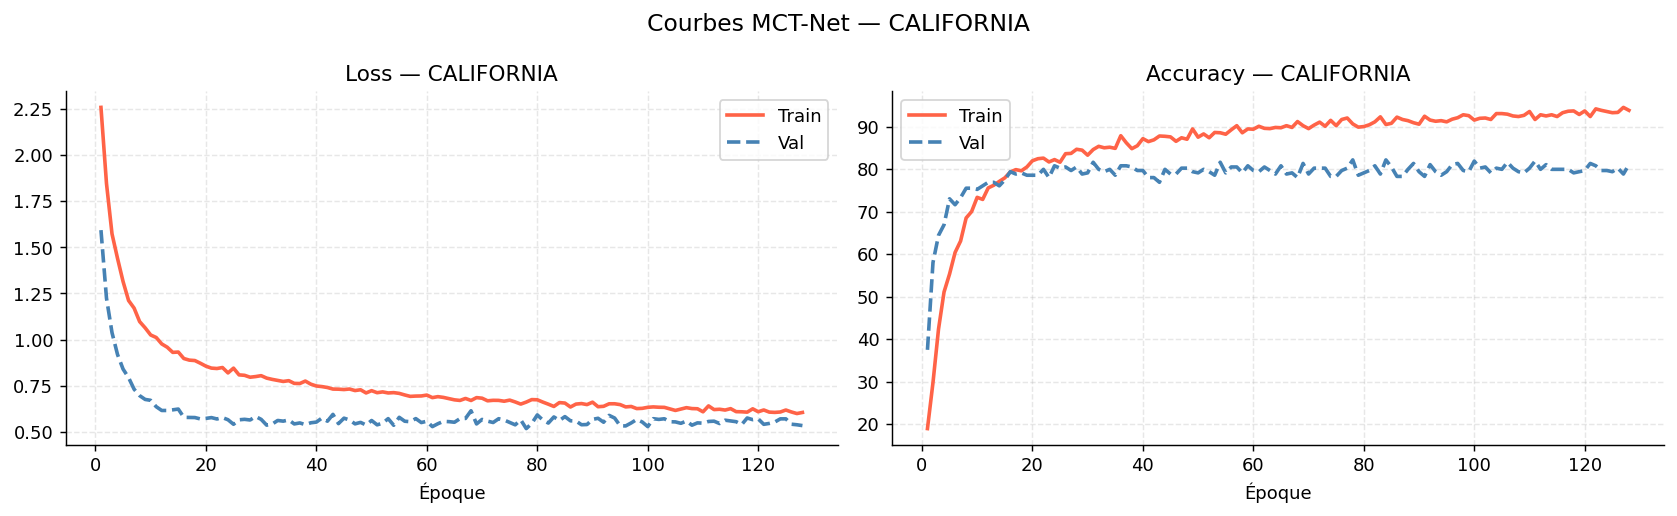

  [CALIFORNIA] Train: Loss=0.6039 Acc=93.89%  |  Val: Loss=0.5325 Acc=81.11%


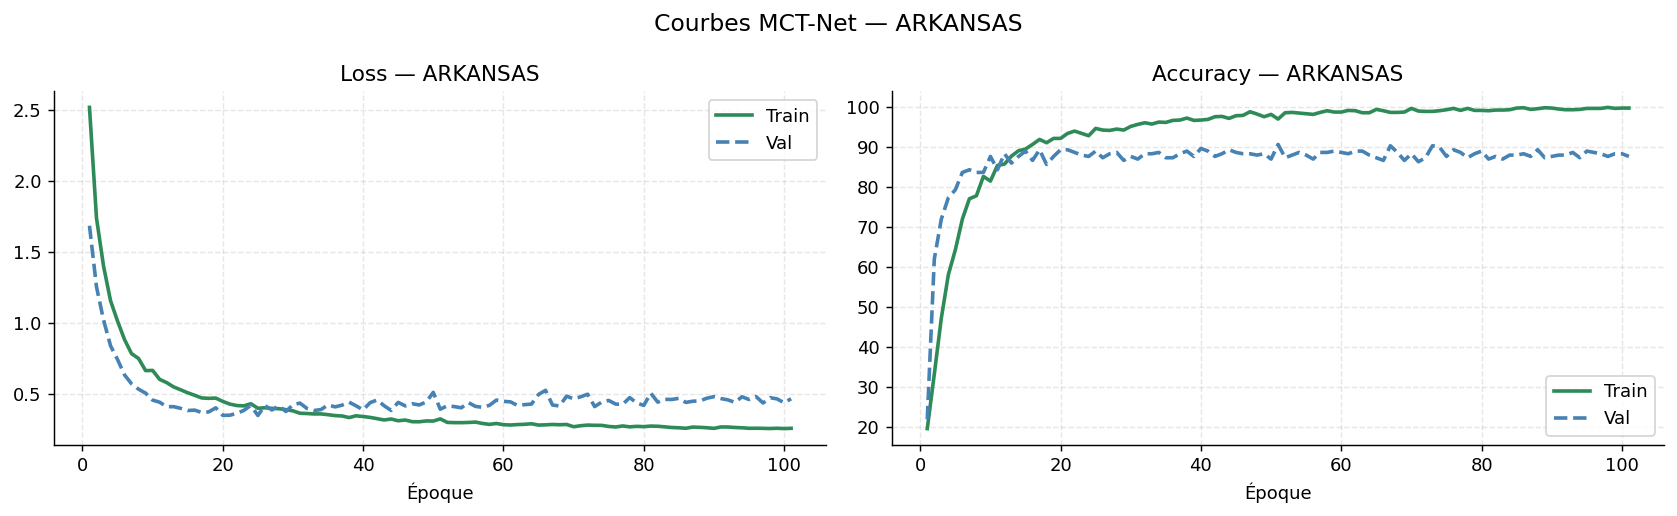

  [ARKANSAS] Train: Loss=0.2597 Acc=99.75%  |  Val: Loss=0.4675 Acc=87.67%


In [19]:
def plot_history(history, label, color='tomato'):
    epochs = range(1, len(history['loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    axes[0].plot(epochs, history['loss'],     color=color,      linewidth=2, label='Train')
    axes[0].plot(epochs, history['val_loss'], color='steelblue',linewidth=2, label='Val', linestyle='--')
    axes[0].set_title(f'Loss — {label}'); axes[0].set_xlabel('Époque'); axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(epochs, history['accuracy'],     color=color,      linewidth=2, label='Train')
    axes[1].plot(epochs, history['val_accuracy'], color='steelblue',linewidth=2, label='Val', linestyle='--')
    axes[1].set_title(f'Accuracy — {label}'); axes[1].set_xlabel('Époque'); axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.suptitle(f'Courbes MCT-Net — {label}', fontsize=13)
    plt.tight_layout(); plt.show()
    print(f'  [{label}] Train: Loss={history["loss"][-1]:.4f} Acc={history["accuracy"][-1]:.2f}%'
          f'  |  Val: Loss={history["val_loss"][-1]:.4f} Acc={history["val_accuracy"][-1]:.2f}%')

plot_history(history_CA, 'CALIFORNIA', color='tomato')
plot_history(history_AR, 'ARKANSAS',   color='seagreen')

### 🧪 Évaluation sur le jeu de TEST

In [20]:
def evaluate_test(model, X_test, m_test, y_test, le, device, label):
    model.eval()
    X_t = torch.tensor(X_test, dtype=torch.float32).to(device)
    m_t = torch.tensor(m_test, dtype=torch.float32).to(device)
    y_t = torch.tensor(y_test, dtype=torch.long).to(device)
    with torch.no_grad():
        outputs      = model(X_t, m_t)
        _, predicted = torch.max(outputs, 1)
        acc = 100 * (predicted == y_t).sum().item() / len(y_t)
    pred_np = predicted.cpu().numpy()
    from sklearn.metrics import cohen_kappa_score, f1_score
    kappa = cohen_kappa_score(y_test, pred_np)
    f1    = f1_score(y_test, pred_np, average='macro')
    print(f'[{label}] OA:{acc/100:.4f}  Kappa:{kappa:.4f}  F1-macro:{f1:.4f}')
    print(f'  Classes: {list(le.classes_)}  N_test={len(y_test)}')
    return acc, pred_np


test_acc_CA, pred_CA = evaluate_test(model_CA, X_test_CA, m_test_CA, y_test_CA, le_CA, DEVICE, 'CALIFORNIA')
test_acc_AR, pred_AR = evaluate_test(model_AR, X_test_AR, m_test_AR, y_test_AR, le_AR, DEVICE, 'ARKANSAS')


[CALIFORNIA] OA:0.8183  Kappa:0.7633  F1-macro:0.7425
  Classes: [np.str_('Alfalfa'), np.str_('Almonds'), np.str_('Grapes'), np.str_('Others'), np.str_('Pistachios'), np.str_('Rice')]  N_test=8200
[ARKANSAS] OA:0.8459  Kappa:0.7776  F1-macro:0.7876
  Classes: [np.str_('Corn'), np.str_('Cotton'), np.str_('Others'), np.str_('Rice'), np.str_('Soybeans')]  N_test=8500


### Profils NDVI — Fig. 2 du paper

  NDVI Arkansas sauvegardé -> data\processed\ndvi_arkansas.png


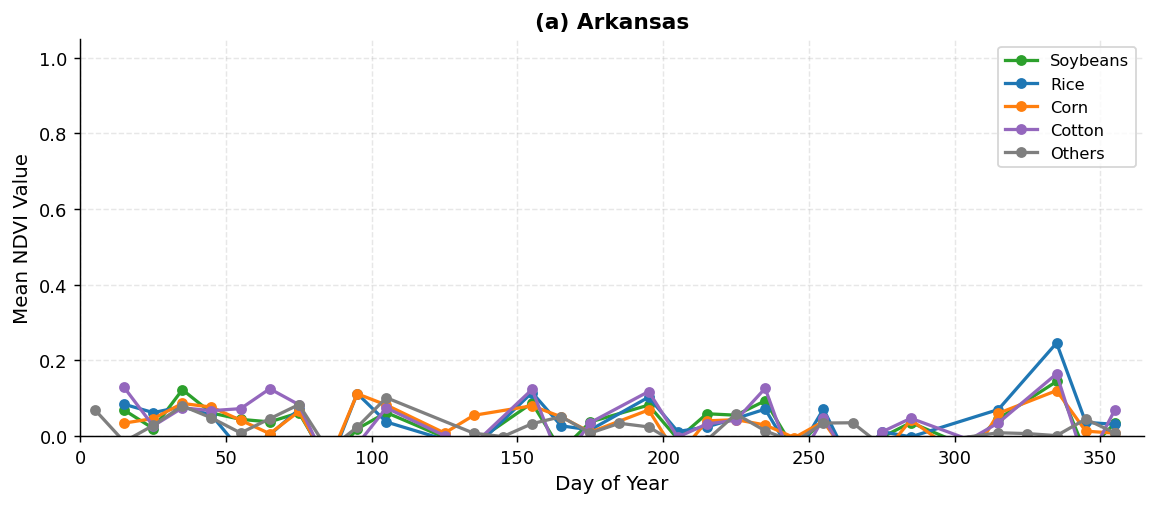

  NDVI California sauvegardé -> data\processed\ndvi_california.png


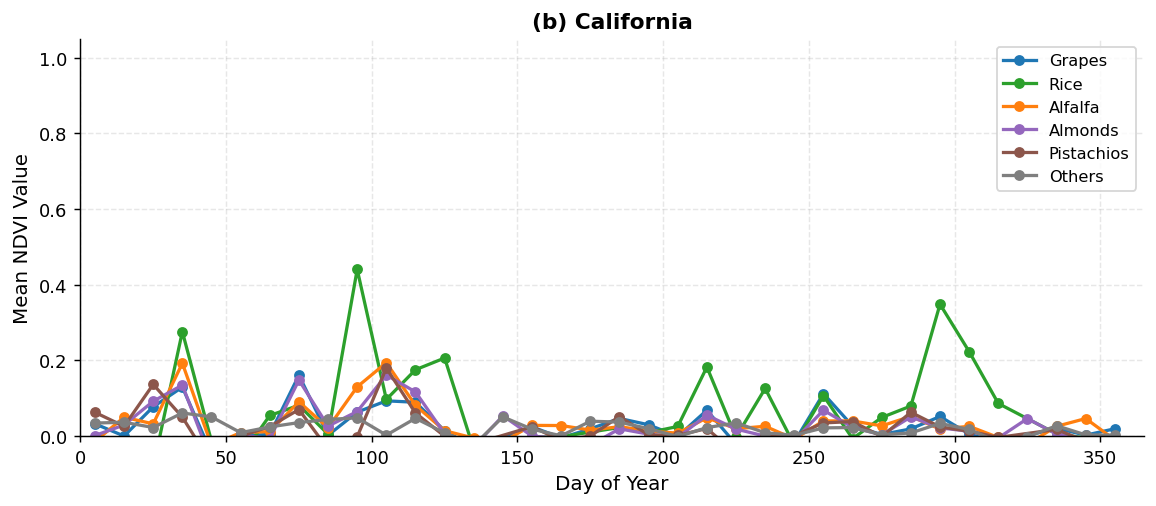

In [21]:
CA_COLORS = {
    'Grapes':'#1f77b4','Rice':'#2ca02c','Alfalfa':'#ff7f0e',
    'Almonds':'#9467bd','Pistachios':'#8c564b','Others':'#7f7f7f'
}
AR_COLORS = {
    'Soybeans':'#2ca02c','Rice':'#1f77b4','Corn':'#ff7f0e',
    'Cotton':'#9467bd','Others':'#7f7f7f'
}

def plot_ndvi_profiles(csv_path, order, color_map, label, sub='a', label_map=None):
    """Reproduit la Fig. 2 du paper : profils NDVI moyens par culture.
    Compatible CSV WIDE (label) et CSV SAFE (crop_label).
    """
    df = pd.read_csv(csv_path)
    # Détecte le format du CSV
    if 'crop_label' in df.columns:
        feat_cols = [c for c in df.columns if c not in ['crop_label','split']]
        raw_labels = df['crop_label'].values
    else:
        feat_cols = [c for c in df.columns if c != 'label']
        # CSV WIDE : réordonner les colonnes comme dans _prepare_wide
        def sort_key(col):
            band, t = col.rsplit('_t', 1)
            return (BAND_ORDER_WIDE.index(band), int(t))
        feat_cols = sorted(feat_cols, key=sort_key)
        # Mapper les codes CDL vers noms si label_map fourni
        if label_map is not None:
            raw_labels = np.array([label_map.get(int(v), str(int(v))) for v in df['label'].values])
        else:
            raw_labels = df['label'].astype(str).values
        # Réordonner les bandes vers ALL_BANDS (NIR=idx 3, RED=idx 2)
        band_map = {'B02':'B2','B03':'B3','B04':'B4','B05':'B5','B06':'B6',
                    'B07':'B7','B08':'B8','B8A':'B8A','B11':'B11','B12':'B12'}
        wide_to_paper = []
        for pb in ALL_BANDS:
            bi = BAND_ORDER_WIDE.index(band_map[pb])
            for t in range(36):
                wide_to_paper.append(bi * 36 + t)
        feat_array = df[feat_cols].values[:, wide_to_paper].astype(float)
        X = feat_array.reshape(-1, 36, N_BANDS)
        # ALL_BANDS = ['B02','B03','B04','B08','B05','B06','B07','B8A','B11','B12']
        # Après wide_to_paper : IDX_NIR=3 (B08), IDX_RED=2 (B04) ← identiques aux globals
        labels = raw_labels
    if 'crop_label' in df.columns:
        # CSV SAFE : colonnes déjà dans l'ordre ALL_BANDS
        X = df[feat_cols].values.reshape(-1, 36, N_BANDS).astype(float)
        labels = raw_labels

    # Pour le mode WIDE, utiliser les indices dans ALL_BANDS (après réordonnancement)
    # ALL_BANDS = ['B02','B03','B04','B08','B05','B06','B07','B8A','B11','B12']
    # IDX_NIR = 3 (B08=NIR), IDX_RED = 2 (B04=Red) — définis en cellule config
    NIR  = X[:, :, IDX_NIR]
    RED  = X[:, :, IDX_RED]
    # Seuil réaliste : masquer les slots où NIR ou RED sont quasi-nuls
    # (slots manquants ou valeurs aberrantes → artefacts NDVI=±1)
    MIN_REFL = 0.01   # seuil minimal de réflectance (données normalisées ~0-1)
    valid_slot = (NIR > MIN_REFL) & (RED > MIN_REFL)
    NDVI = np.where(valid_slot,
                    (NIR - RED) / (NIR + RED + 1e-8),
                    np.nan)
    # Clip NDVI dans [-0.1, 1.0] pour éliminer les artefacts résiduels
    NDVI = np.clip(NDVI, -0.1, 1.0)

    fig, ax = plt.subplots(figsize=(9, 4))
    for cls in order:
        idx = labels == cls
        if idx.sum() == 0:
            continue
        mean_ndvi = np.nanmean(NDVI[idx], axis=0)
        coverage  = (~np.isnan(NDVI[idx])).mean(axis=0)
        valid     = coverage >= 0.1
        doys      = np.array(TARGET_DOYS)
        ax.plot(doys[valid], mean_ndvi[valid],
                marker='o', markersize=5, linewidth=1.8,
                color=color_map.get(cls, 'gray'), label=cls)

    ax.set_xlabel('Day of Year', fontsize=11)
    ax.set_ylabel('Mean NDVI Value', fontsize=11)
    ax.set_title(f'({sub}) {label}', fontsize=12, fontweight='bold')
    ax.set_xlim(0, 365)
    ax.set_ylim(0, 1.05)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(50))
    ax.legend(loc='upper right', fontsize=9, framealpha=0.8)
    ax.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    try:
        out_path = PROCESSED_DIR / f'ndvi_{label.lower()}.png'
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f'  NDVI {label} sauvegardé -> {out_path}')
    except Exception:
        out_path = Path(f'ndvi_{label.lower()}.png')
        plt.savefig(out_path, dpi=150, bbox_inches='tight')
        print(f'  NDVI {label} sauvegardé -> {out_path}')
    plt.show()


# Utilise les CSV WIDE si disponibles, sinon les CSV SAFE
ndvi_csv_AR = TRAIN_CSV_WIDE_AR if TRAIN_CSV_WIDE_AR.exists() else TRAIN_CSV_AR
ndvi_csv_CA = TRAIN_CSV_WIDE_CA if TRAIN_CSV_WIDE_CA.exists() else TRAIN_CSV_CA

plot_ndvi_profiles(ndvi_csv_AR, ['Soybeans','Rice','Corn','Cotton','Others'], AR_COLORS, 'Arkansas', 'a', label_map=AR_LABEL_MAP)
plot_ndvi_profiles(ndvi_csv_CA, CA_ORDER, CA_COLORS, 'California', 'b', label_map=CA_LABEL_MAP)


### Matrices de confusion normalisees — Fig. 7 & 8 du paper

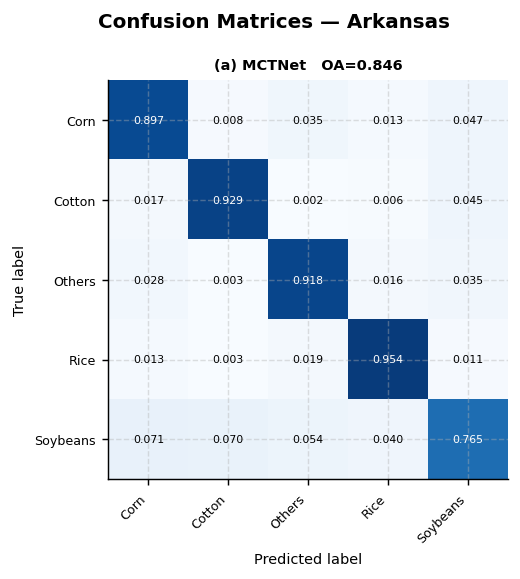

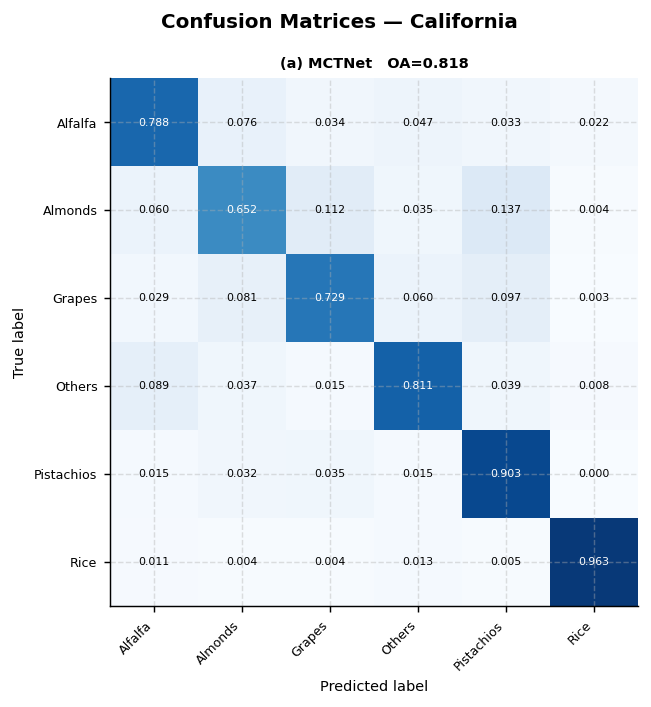

Matrices sauvegardees dans data\processed


In [22]:
def plot_confusion_matrix(y_true, y_pred, classes, title='', ax=None):
    """Matrice de confusion normalisee avec valeurs — style Fig. 7/8 du paper."""
    cm = confusion_matrix(y_true, y_pred, normalize='true')
    n  = len(classes)
    if ax is None:
        fig, ax = plt.subplots(figsize=(4.5, 4))
    ax.imshow(cm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(n))
    ax.set_xticklabels(classes, fontsize=7, rotation=45, ha='right')
    ax.set_yticks(range(n))
    ax.set_yticklabels(classes, fontsize=7)
    ax.set_xlabel('Predicted label', fontsize=8)
    ax.set_ylabel('True label', fontsize=8)
    ax.set_title(title, fontsize=8, fontweight='bold')
    for i in range(n):
        for j in range(n):
            color = 'white' if cm[i, j] > 0.5 else 'black'
            ax.text(j, i, f'{cm[i,j]:.3f}', ha='center', va='center',
                    fontsize=6, color=color)


# Arkansas — Fig. 7
fig, ax = plt.subplots(1, 1, figsize=(5, 4.5))
oa_ar = (pred_AR == y_test_AR).mean()
plot_confusion_matrix(y_test_AR, pred_AR, le_AR.classes_,
                      title=f'(a) MCTNet   OA={oa_ar:.3f}', ax=ax)
plt.suptitle('Confusion Matrices — Arkansas', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'confusion_arkansas.png', dpi=150, bbox_inches='tight')
plt.show()

# California — Fig. 8
fig, ax = plt.subplots(1, 1, figsize=(6, 5.5))
oa_ca = (pred_CA == y_test_CA).mean()
plot_confusion_matrix(y_test_CA, pred_CA, le_CA.classes_,
                      title=f'(a) MCTNet   OA={oa_ca:.3f}', ax=ax)
plt.suptitle('Confusion Matrices — California', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'confusion_california.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Matrices sauvegardees dans {PROCESSED_DIR}')


### 💾 Sauvegarde du modèle

In [23]:
def save_model(model, path, num_classes, le, scaler, history, test_acc, n_dates, label):
    torch.save({
        'model_state_dict': model.state_dict(),
        'num_classes'     : num_classes,
        'label_classes'   : list(le.classes_),
        'scaler'          : scaler,
        'history'         : history,
        'test_accuracy'   : test_acc,
        'n_dates'         : n_dates,
        'n_bands'         : N_BANDS,
    }, path)
    print(f'✅ [{label}] Modèle sauvegardé : {path}')
    print(f'   Accuracy test : {test_acc:.2f}%')

save_model(model_CA, MODEL_PATH_CA, num_classes_CA, le_CA, scaler_CA, history_CA, test_acc_CA, len(DATES_MAP_CA), 'CALIFORNIA')
save_model(model_AR, MODEL_PATH_AR, num_classes_AR, le_AR, scaler_AR, history_AR, test_acc_AR, len(DATES_MAP_AR), 'ARKANSAS')

print('\n🎉 Pipeline MCT-Net complet — California + Arkansas terminé !')


✅ [CALIFORNIA] Modèle sauvegardé : models\mctnet_california_final.pth
   Accuracy test : 81.83%
✅ [ARKANSAS] Modèle sauvegardé : models\mctnet_arkansas_final.pth
   Accuracy test : 84.59%

🎉 Pipeline MCT-Net complet — California + Arkansas terminé !
